#Problem Statement & Hypothesis

####Import Statements

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

CROP DATA

In [2]:
sitc_codes = [
    '0411',    # Wheat
    '0421',    # Rice paddy
    '044',     # Maize
    '0541',    # Potatoes
    '05488',   # Sugar cane
    '05774',   # Almonds
    '2223',    # Seed cotton
    '0721',    # Cocoa beans
]

raw = pd.read_csv('CropData.csv', header=None, nrows=5, encoding='latin1', low_memory=False)
province_row = raw.iloc[4]
cntry_avg_positions = [i for i, v in enumerate(province_row) if str(v).strip() == 'CNTRY-average']

#Read data with countries as header
df = pd.read_csv('CropData.csv', header=3, encoding='latin1', low_memory=False)
df.columns = df.columns.str.strip()

#Keep relevant columns
metadata_positions = [2, 4, 8, 9]
keep_positions = metadata_positions + cntry_avg_positions
df_country_only = df.iloc[:, keep_positions].copy()

#Create headers
country_row = raw.iloc[3]
c_country_names = [str(country_row.iloc[i]).strip() for i in cntry_avg_positions]
new_col_names = ['SITC', 'Product Name', 'WF Type', 'Global average'] + c_country_names
df_country_only.columns = new_col_names

#Get the crops we want
match_indices = df_country_only.index[
    df_country_only['SITC'].isin(sitc_codes)
].tolist()

#Keep only the first match of the sitc code
seen_sitc = set()
deduped_match_indices = []
for idx in match_indices:
    sitc = df_country_only.at[idx, 'SITC']
    if sitc not in seen_sitc:
        seen_sitc.add(sitc)
        deduped_match_indices.append(idx)

#Get WF types for each row
rows_to_keep = []
for idx in deduped_match_indices:
    for offset in [0, 1, 2]:
        if (idx + offset) in df_country_only.index:
            rows_to_keep.append(idx + offset)

result = df_country_only.loc[rows_to_keep].copy().reset_index(drop=True)
result['SITC'] = result['SITC'].replace('nan', '')

#Convert country columns to numeric for analysis
for i in range(4, result.shape[1]):
    result.iloc[:, i] = pd.to_numeric(
        result.iloc[:, i].astype(str).str.replace(r"^'", '', regex=True),
        errors='coerce'
    )

print(f"Matched {len(deduped_match_indices)} unique products, {len(result)} total rows")

result.to_csv('crops_by_country.csv', index=False)


FileNotFoundError: [Errno 2] No such file or directory: 'CropData.csv'

ANIMAL DATA

In [ ]:
sitc_codes = [
    '00111',  #Bovine
    '00121',   #Sheep
    '00131',   #Swine
    '00149',  #Poultry
    '02223', #Milk/Cream
    '0230a', #Butter
    '0241',  #Cheese
    '0251' #Bird eggs
]

a_raw = pd.read_csv('AnimalData.csv', header=None, nrows=5, encoding='latin1')
country_row = a_raw.iloc[2].ffill()  # Fill country names to the right
system_row = a_raw.iloc[3].str.strip()

target_systems = ['Grazing', 'Mixed', 'Industrial', 'Weighted average']
selected_indices = [1, 3]
new_headers = ['SITC', 'Product Name']

#Get target columns
for i in range(4, len(system_row)):
    sys_name = str(system_row.iloc[i])
    if sys_name in target_systems:
        country = str(country_row.iloc[i])
        selected_indices.append(i)
        # Create unique header: "Country - System"
        new_headers.append(f"{country} - {sys_name}")

#Load data
df_a = pd.read_csv('AnimalData.csv', header=None, skiprows=4, encoding='latin1')
result = df_a.iloc[:, selected_indices].copy()
result.columns = new_headers

#Clean sitc
result['SITC'] = result['SITC'].astype(str).str.strip().str.replace(r"^'", '', regex=True)
match_indices = result.index[result['SITC'].isin(sitc_codes)].tolist()

#Get WF types for each row
rows_to_keep = []
for idx in match_indices:
    rows_to_keep.extend([idx, idx+1, idx+2])

result = result.loc[rows_to_keep].copy().reset_index(drop=True)

# 6. FIX: Use iloc for numeric conversion to avoid the AttributeError
for i in range(2, result.shape[1]):
    result.iloc[:, i] = pd.to_numeric(
        result.iloc[:, i].astype(str).str.replace(r"^'", '', regex=True),
        errors='coerce'
    )

# 7. Final clean and export
result['SITC'] = result['SITC'].replace('nan', '')
result.to_csv('anim_by_country.csv', index=False)

print(f"Successfully created CSV with {result.shape[1]} columns.")

In [ ]:
# Read raw file to get structure
a_raw = pd.read_csv('AnimalData.csv', header=None, nrows=4, encoding='latin1', low_memory=False)
prod_row = a_raw.iloc[3]

# Find 'Weighted average' column positions
weighted_positions = [i for i, v in enumerate(prod_row) if str(v).strip() == 'Weighted average']

# Read main data with row 2 as header
df_a = pd.read_csv('AnimalData.csv', header=2, encoding='latin1', low_memory=False)
df_a.columns = df_a.columns.str.strip()

# Keep only metadata columns and the selected 'Weighted average' columns
# Metadata columns are SITC (index 1), Product Name (index 3), and WF Type (index 8, which contains Green/Blue/Grey)
metadata_positions2 = [1, 3, 8]
a_keep_positions = metadata_positions2 + weighted_positions
df_a_weighted_only = df_a.iloc[:, a_keep_positions].copy()

# Rename metadata columns
df_a_weighted_only.columns.values[0] = 'SITC'
df_a_weighted_only.columns.values[1] = 'Product Name'
df_a_weighted_only.columns.values[2] = 'WF Type' # This column contains Green/Blue/Grey

# Rename country-specific weighted average columns
a_country_row = a_raw.iloc[2]
# Create new column names for the weighted average values, including " - Weighted average"
weighted_avg_col_names = [
    str(a_country_row.iloc[i]).strip() + ' - Weighted average'
    for i in weighted_positions
]
df_a_weighted_only.columns = (
    df_a_weighted_only.columns[:3].tolist() + weighted_avg_col_names
)

# Clean SITC column and filter by code list
df_a_weighted_only['SITC'] = (
    df_a_weighted_only['SITC']
    .astype(str).str.strip().str.replace(r"^'", '', regex=True)
)

match_indices2 = df_a_weighted_only.index[
    df_a_weighted_only['SITC'].isin(sitc_codes)
].tolist()

# Collect indices including next 2 rows (Green, Blue, Grey) for each product
rows_to_keep2 = set()
for idx in match_indices2:
    rows_to_keep2.add(idx)
    rows_to_keep2.add(idx + 1)
    rows_to_keep2.add(idx + 2)

rows_to_keep2 = sorted([i for i in rows_to_keep2 if i in df_a_weighted_only.index])
a_result = df_a_weighted_only.loc[rows_to_keep2].copy().reset_index(drop=True)

# Convert country columns (from index 3 onwards) to numeric
for i in range(3, a_result.shape[1]):
    a_result.iloc[:, i] = pd.to_numeric(
        a_result.iloc[:, i].astype(str).str.replace(r"^'", '', regex=True),
        errors='coerce'
    )

a_result['SITC'] = a_result['SITC'].str.replace('nan', '')

a_result.to_csv('anim_by_country.csv', index=False)
print(f"Successfully created anim_by_country.csv with shape {a_result.shape} and columns: {a_result.columns.tolist()}")

# Agricultural Water Footprint Analysis: Who Grows More with Less Water?

## Problem Statement & Hypothesis

**Research Question:** Across 16 major agricultural products, which countries achieve the lowest water footprint per unit of output, and what does the green-blue-grey decomposition reveal about whether that efficiency comes from favorable climate, irrigation technology, or pollution management?

**Track:** Sustainability & Critical Infrastructure

**Hypothesis:** We hypothesize that water footprint efficiency varies dramatically across countries for the same product, and that the green-blue-grey decomposition reveals distinct efficiency profiles — countries in temperate/humid climates will show green-dominant (rain-fed) footprints, arid-region producers will show high blue (irrigation) shares, and industrialized nations will show elevated grey (pollution) footprints from fertilizer-intensive agriculture.

**Why This Matters:** Agriculture accounts for ~70% of global freshwater withdrawals. Understanding which countries produce food most water-efficiently — and *why* — directly informs trade policy, investment in irrigation infrastructure, and climate adaptation strategies. As water scarcity intensifies under climate change, these insights become critical for global food security planning.

## Dataset Description

We use three primary data sources covering 16 agricultural products across ~200 countries:

**1. Water Footprint Network — Report 47 (Crops):** Green, blue, and grey water footprint (m³/ton) for 8 crop products. Data represents 1996–2005 national averages. Source: Mekonnen & Hoekstra (2010).

**2. Water Footprint Network — Report 48 (Animals):** Green, blue, and grey water footprint (m³/ton) for 4 animal types and 4 animal products, broken down by production system (grazing, mixed, industrial) with weighted national averages. Source: Mekonnen & Hoekstra (2012).

**3. FAOSTAT Production Data:** Production volumes in metric tons for all 16 products, for years 2005 (matching the WF study period) and 2024 (most recent available).

| Category | Products |
|----------|----------|
| Crops (8) | Wheat, Rice, Maize, Potatoes, Sugar Cane, Almonds, Seed Cotton, Cocoa Beans |
| Animals (4) | Bovine, Swine, Sheep, Poultry |
| Animal Products (4) | Eggs, Milk, Butter, Cheese |

**Key Definitions:**
- **Green WF:** Rainwater consumed (evapotranspired) — reflects climate advantage
- **Blue WF:** Surface/groundwater consumed — reflects irrigation dependence
- **Grey WF:** Water needed to dilute pollutants to standards — reflects pollution intensity
- **Total WF:** Green + Blue + Grey (m³ per ton of product)

## Data Loading & Preprocessing

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import silhouette_score
from scipy import stats
from scipy.stats import kruskal

### Load and reshape crop water footprint data

In [ ]:
# Load crop water footprint data (cleaned from WFN Report 47)
crops_raw = pd.read_csv('crops_by_country.csv')
print(f"Crops raw shape: {crops_raw.shape}")

# Forward-fill Product Name and SITC (each product spans 3 rows: Green, Blue, Grey)
crops_raw['Product Name'] = crops_raw['Product Name'].ffill()
crops_raw['SITC'] = crops_raw['SITC'].ffill()

# Assign WF Type based on repeating row pattern
crops_raw['WF Type'] = ['Green', 'Blue', 'Grey'] * (len(crops_raw) // 3)

# Country columns start at index 4
country_cols_c = crops_raw.columns[4:]

# Melt to long format
crops_long = crops_raw.melt(
    id_vars=['SITC', 'Product Name', 'WF Type', 'Global average'],
    value_vars=country_cols_c,
    var_name='Country',
    value_name='WF_value'
)

# Pivot: one row per country-product with Green/Blue/Grey columns
crops_pivot = crops_long.pivot_table(
    index=['Product Name', 'Country'],
    columns='WF Type',
    values='WF_value',
    aggfunc='first'
).reset_index()

crops_pivot.columns = [str(c) for c in crops_pivot.columns]
crops_pivot.columns.name = None
crops_pivot = crops_pivot.rename(columns={'Green': 'Green_WF', 'Blue': 'Blue_WF', 'Grey': 'Grey_WF'})
crops_pivot['Total_WF'] = crops_pivot['Green_WF'] + crops_pivot['Blue_WF'] + crops_pivot['Grey_WF']
crops_pivot['Category'] = 'Crop'
crops_pivot = crops_pivot.dropna(subset=['Green_WF', 'Blue_WF', 'Grey_WF'], how='all')

# Standardize product names
crop_name_map = {
    'Wheat': 'Wheat', 'Rice, paddy': 'Rice', 'Maize': 'Maize',
    'Potatoes': 'Potatoes', 'Sugar cane': 'Sugar Cane',
    'Almonds, with shell': 'Almonds', 'Seed cotton': 'Seed Cotton',
    'Cocoa beans': 'Cocoa Beans'
}
crops_pivot['Product Name'] = crops_pivot['Product Name'].map(crop_name_map).fillna(crops_pivot['Product Name'])

print(f"Crops long format: {crops_pivot.shape}")
print(f"Products: {crops_pivot['Product Name'].nunique()}")
print(f"Countries: {crops_pivot['Country'].nunique()}")

Crops raw shape: (24, 209)
Crops long format: (831, 7)
Products: 8
Countries: 190


### Load and reshape animal water footprint data (weighted averages only)

In [ ]:
# Load animal water footprint data (cleaned from WFN Report 48)
# This CSV contains ALL production systems (Grazing, Mixed, Industrial, Weighted average)
# We extract ONLY the Weighted average columns for cross-product comparison
anim_raw = pd.read_csv('anim_by_country.csv')
print(f"Animal raw shape (all systems): {anim_raw.shape}")

# Extract only Weighted average columns
wa_cols = [c for c in anim_raw.columns if 'Weighted average' in c]
countries_a = [c.replace(' - Weighted average', '') for c in wa_cols]

# Build clean weighted-average-only dataframe
anim_clean = anim_raw[['SITC', 'Product Name']].copy()
wa_data = anim_raw[wa_cols].copy()
wa_data.columns = countries_a
anim_clean = pd.concat([anim_clean, wa_data], axis=1)

print(f"After filtering to weighted averages: {anim_clean.shape}")

# Forward-fill Product Name and SITC
anim_clean['Product Name'] = anim_clean['Product Name'].ffill()
anim_clean['SITC'] = anim_clean['SITC'].ffill()

# Assign WF Type based on repeating row pattern
anim_clean['WF Type'] = ['Green', 'Blue', 'Grey'] * (len(anim_clean) // 3)

# Standardize product names
product_name_map = {
    'Bov.animals,pure,breedng': 'Bovine',
    'Swine,pure,for breeding': 'Swine',
    'Sheep, live': 'Sheep',
    'Poultry, live,over 185g': 'Poultry',
    'Milk,cream unsweetened': 'Milk',
    'butter': 'Butter',
    'Cheese, powdered, grated': 'Cheese',
    "Birds' eggs, in shell": 'Eggs'
}
anim_clean['Product Name'] = anim_clean['Product Name'].map(product_name_map)

# Separate World Average before melting
world_avg_col = 'World Average'
country_cols_a = [c for c in countries_a if c != world_avg_col]

# Melt to long format
anim_long = anim_clean.melt(
    id_vars=['SITC', 'Product Name', 'WF Type'],
    value_vars=country_cols_a,
    var_name='Country',
    value_name='WF_value'
)

# Pivot: one row per country-product with Green/Blue/Grey columns
anim_pivot = anim_long.pivot_table(
    index=['Product Name', 'Country'],
    columns='WF Type',
    values='WF_value',
    aggfunc='first'
).reset_index()

anim_pivot.columns = [str(c) for c in anim_pivot.columns]
anim_pivot.columns.name = None
anim_pivot = anim_pivot.rename(columns={'Green': 'Green_WF', 'Blue': 'Blue_WF', 'Grey': 'Grey_WF'})
anim_pivot['Total_WF'] = anim_pivot['Green_WF'] + anim_pivot['Blue_WF'] + anim_pivot['Grey_WF']

# Categorize
animal_types = ['Bovine', 'Swine', 'Sheep', 'Poultry']
anim_pivot['Category'] = anim_pivot['Product Name'].apply(
    lambda x: 'Animal' if x in animal_types else 'Animal Product'
)
anim_pivot = anim_pivot.dropna(subset=['Green_WF', 'Blue_WF', 'Grey_WF'], how='all')

print(f"Animal long format: {anim_pivot.shape}")
print(f"Products: {anim_pivot['Product Name'].nunique()}")
print(f"Countries: {anim_pivot['Country'].nunique()}")

Animal raw shape (all systems): (24, 207)
After filtering to weighted averages: (24, 206)
Animal long format: (1632, 7)
Products: 8
Countries: 204


### Combine into unified master DataFrame

In [ ]:
# Combine crops and animals into one master DataFrame
master = pd.concat([
    crops_pivot[['Product Name', 'Country', 'Green_WF', 'Blue_WF', 'Grey_WF', 'Total_WF', 'Category']],
    anim_pivot[['Product Name', 'Country', 'Green_WF', 'Blue_WF', 'Grey_WF', 'Total_WF', 'Category']]
], ignore_index=True)

# Remove rows where Total_WF is zero or negative (invalid)
master = master[master['Total_WF'] > 0].copy()

# Calculate percentage shares
master['Green_pct'] = (master['Green_WF'] / master['Total_WF'] * 100).round(1)
master['Blue_pct'] = (master['Blue_WF'] / master['Total_WF'] * 100).round(1)
master['Grey_pct'] = (master['Grey_WF'] / master['Total_WF'] * 100).round(1)

# Add region mapping
region_map = {
    'Afghanistan': 'South Asia', 'Albania': 'Europe', 'Algeria': 'Africa', 'Angola': 'Africa',
    'Argentina': 'South America', 'Armenia': 'Asia', 'Australia': 'Oceania', 'Austria': 'Europe',
    'Azerbaijan': 'Asia', 'Azerbaijan, Republic of': 'Asia', 'Bangladesh': 'South Asia',
    'Belarus': 'Europe', 'Belgium': 'Europe', 'Benin': 'Africa', 'Bhutan': 'South Asia',
    'Bolivia': 'South America', 'Bosnia and Herzegovina': 'Europe', 'Botswana': 'Africa',
    'Brazil': 'South America', 'Bulgaria': 'Europe', 'Burkina Faso': 'Africa',
    'Myanmar': 'Asia', 'Burundi': 'Africa', 'Cambodia': 'Asia', 'Cameroon': 'Africa',
    'Canada': 'North America', 'Central African Republic': 'Africa', 'Chad': 'Africa',
    'Chile': 'South America', 'China': 'Asia', 'Colombia': 'South America',
    'Congo': 'Africa', 'Congo, Democratic Republic of': 'Africa', 'Congo, Dem Republic of': 'Africa',
    'Congo, Republic of': 'Africa',
    'Costa Rica': 'Central America', "CÃ´te d'Ivoire": 'Africa', 'Croatia': 'Europe',
    'Cuba': 'Central America', 'Cyprus': 'Europe', 'Czech Republic': 'Europe',
    'Denmark': 'Europe', 'Dominican Republic': 'Central America', 'Ecuador': 'South America',
    'Egypt': 'Africa', 'El Salvador': 'Central America', 'Eritrea': 'Africa',
    'Estonia': 'Europe', 'Ethiopia': 'Africa', 'Fiji': 'Oceania', 'Fiji Islands': 'Oceania',
    'Finland': 'Europe', 'France': 'Europe', 'Gabon': 'Africa', 'Gambia': 'Africa',
    'Georgia': 'Asia', 'Germany': 'Europe', 'Ghana': 'Africa', 'Greece': 'Europe',
    'Guatemala': 'Central America', 'Guinea': 'Africa', 'Guinea-Bissau': 'Africa',
    'Guyana': 'South America', 'Haiti': 'Central America', 'Honduras': 'Central America',
    'Hungary': 'Europe', 'Iceland': 'Europe', 'India': 'South Asia', 'Indonesia': 'Asia',
    'Iran, Islamic Republic of': 'Middle East', 'Iran, Islamic Rep of': 'Middle East',
    'Iraq': 'Middle East', 'Ireland': 'Europe', 'Israel': 'Middle East', 'Italy': 'Europe',
    'Jamaica': 'Central America', 'Japan': 'Asia', 'Jordan': 'Middle East',
    'Kazakhstan': 'Asia', 'Kenya': 'Africa', 'Korea, Republic of': 'Asia',
    "Korea, Dem People's Rep": 'Asia', 'Korea, Democratic People\'s Republic of': 'Asia',
    'Kuwait': 'Middle East', 'Kyrgyzstan': 'Asia',
    "Lao People's Democratic Republic": 'Asia', 'Laos': 'Asia',
    'Latvia': 'Europe', 'Lebanon': 'Middle East', 'Lesotho': 'Africa',
    'Liberia': 'Africa', 'Libyan Arab Jamahiriya': 'Africa', 'Lithuania': 'Europe',
    'Luxembourg': 'Europe', 'Macedonia , The Former Yugoslav Republic of': 'Europe',
    'Macedonia,The Fmr Yug Rp': 'Europe',
    'Madagascar': 'Africa', 'Malawi': 'Africa', 'Malaysia': 'Asia', 'Mali': 'Africa',
    'Mauritania': 'Africa', 'Mauritius': 'Africa', 'Mexico': 'North America',
    'Moldova': 'Europe', 'Moldova, Republic of': 'Europe', 'Mongolia': 'Asia',
    'Morocco': 'Africa', 'Mozambique': 'Africa', 'Namibia': 'Africa',
    'Nepal': 'South Asia', 'Netherlands': 'Europe', 'New Zealand': 'Oceania',
    'Nicaragua': 'Central America', 'Niger': 'Africa', 'Nigeria': 'Africa',
    'Norway': 'Europe', 'Oman': 'Middle East', 'Pakistan': 'South Asia',
    'Panama': 'Central America', 'Papua New Guinea': 'Oceania', 'Paraguay': 'South America',
    'Peru': 'South America', 'Philippines': 'Asia', 'Poland': 'Europe',
    'Portugal': 'Europe', 'Qatar': 'Middle East', 'Romania': 'Europe',
    'Russian Federation': 'Europe', 'Rwanda': 'Africa', 'Saudi Arabia': 'Middle East',
    'Senegal': 'Africa', 'Serbia and Montenegro': 'Europe', 'Sierra Leone': 'Africa',
    'Slovakia': 'Europe', 'Slovenia': 'Europe', 'Somalia': 'Africa',
    'South Africa': 'Africa', 'Spain': 'Europe', 'Sri Lanka': 'South Asia',
    'Sudan': 'Africa', 'Suriname': 'South America', 'Swaziland': 'Africa',
    'Sweden': 'Europe', 'Switzerland': 'Europe', 'Syrian Arab Republic': 'Middle East',
    'Tajikistan': 'Asia', 'Tanzania, United Republic of': 'Africa',
    'Tanzania, United Rep of': 'Africa',
    'Thailand': 'Asia', 'Togo': 'Africa', 'Trinidad and Tobago': 'Central America',
    'Tunisia': 'Africa', 'Turkey': 'Europe', 'Turkmenistan': 'Asia',
    'Uganda': 'Africa', 'Ukraine': 'Europe', 'United Arab Emirates': 'Middle East',
    'United Kingdom': 'Europe', 'United States of America': 'North America',
    'Uruguay': 'South America', 'Uzbekistan': 'Asia',
    'Venezuela, Bolivarian Republic of': 'South America',
    'Venezuela, Boliv Rep of': 'South America',
    'Viet Nam': 'Asia', 'Yemen': 'Middle East', 'Zambia': 'Africa', 'Zimbabwe': 'Africa',
    'Antigua and Barbuda': 'Central America', 'Bahamas': 'Central America',
    'Bahrain': 'Middle East', 'Barbados': 'Central America', 'Belize': 'Central America',
    'Bermuda': 'North America', 'Brunei Darussalam': 'Asia',
    'Cape Verde': 'Africa', 'Comoros': 'Africa', 'Djibouti': 'Africa',
    'Dominica': 'Central America', 'East Timor': 'Asia', 'Equatorial Guinea': 'Africa',
    'French Guiana': 'South America', 'Grenada': 'Central America',
    'Guadeloupe': 'Central America', 'Occupied Palestinian Territory': 'Middle East',
    'Malta': 'Europe', 'Martinique': 'Central America',
    'Micronesia, Federated States of': 'Oceania', 'Montserrat': 'Central America',
    'New Caledonia': 'Oceania', 'Puerto Rico': 'Central America',
    'RÃ©union': 'Africa', 'Rwanda': 'Africa',
    'Saint Kitts and Nevis': 'Central America', 'Saint Lucia': 'Central America',
    'Saint Vincent and Grenadines': 'Central America', 'Saint Vincent/Grenadines': 'Central America',
    'Samoa': 'Oceania', 'Sao Tome and Principe': 'Africa',
    'Seychelles': 'Africa', 'Singapore': 'Asia',
    'Solomon Islands': 'Oceania', 'Tonga': 'Oceania', 'Vanuatu': 'Oceania',
    'Wallis and Futuna Is': 'Oceania',
    'Saint Pierre and Miquelon': 'North America',
    'Serbia and Montenegro.1': 'Europe',
}
master['Region'] = master['Country'].map(region_map).fillna('Other')

print(f"Master DataFrame shape: {master.shape}")
print(f"Products: {master['Product Name'].nunique()}")
print(f"Countries: {master['Country'].nunique()}")
print(f"\nCategory breakdown:")
print(master.groupby('Category')['Product Name'].nunique())
print(f"\nRegion coverage:")
print(master['Region'].value_counts())

Master DataFrame shape: (2008, 11)
Products: 16
Countries: 214

Category breakdown:
Category
Animal            4
Animal Product    4
Crop              8
Name: Product Name, dtype: int64

Region coverage:
Region
Africa             535
Europe             429
Asia               260
Central America    204
South America      158
Middle East        137
South Asia          87
Oceania             82
Other               72
North America       44
Name: count, dtype: int64


### Merge production data

In [ ]:
# Load FAOSTAT production data
production = pd.read_csv('ProductionData.csv')
print(f"Production data shape: {production.shape}")
print(f"Years: {production['Year'].unique()}")

# Map FAOSTAT item names to our standardized names
prod_name_map = {
    'Wheat': 'Wheat', 'Rice': 'Rice', 'Maize (corn)': 'Maize',
    'Potatoes': 'Potatoes', 'Sugar cane': 'Sugar Cane',
    'Almonds, in shell': 'Almonds', 'Seed cotton, unginned': 'Seed Cotton',
    'Cocoa beans': 'Cocoa Beans',
    'Meat of cattle with the bone, fresh or chilled': 'Bovine',
    'Meat of pig with the bone, fresh or chilled': 'Swine',
    'Meat of sheep, fresh or chilled': 'Sheep',
    'Meat of chickens, fresh or chilled': 'Poultry',
    'Skim milk of cows': 'Milk',
    'Butter of cow milk': 'Butter',
    'Cheese from whole cow milk': 'Cheese',
    'Hen eggs in shell, fresh': 'Eggs'
}
production['Product Name'] = production['Item'].map(prod_name_map)
production = production.dropna(subset=['Product Name'])

# Country name harmonization (FAOSTAT → WaterStat naming)
fao_to_wf = {
    'Bolivia (Plurinational State of)': 'Bolivia',
    'Cabo Verde': 'Cape Verde',
    'China, mainland': 'China',
    "Côte d'Ivoire": "CÃ´te d'Ivoire",
    'Czechia': 'Czech Republic',
    "Democratic People's Republic of Korea": "Korea, Dem People's Rep",
    'Democratic Republic of the Congo': 'Congo, Dem Republic of',
    'Eswatini': 'Swaziland',
    'Iran (Islamic Republic of)': 'Iran, Islamic Rep of',
    'Libya': 'Libyan Arab Jamahiriya',
    'Micronesia (Federated States of)': 'Micronesia, Federated States of',
    'Montenegro': 'Serbia and Montenegro',
    'Netherlands (Kingdom of the)': 'Netherlands',
    'North Macedonia': 'Macedonia,The Fmr Yug Rp',
    'Palestine': 'Occupied Palestinian Territory',
    'Republic of Korea': 'Korea, Republic of',
    'Republic of Moldova': 'Moldova, Republic of',
    'Serbia': 'Serbia and Montenegro',
    'Sudan (former)': 'Sudan',
    'South Sudan': 'Sudan',
    'Timor-Leste': 'East Timor',
    'Türkiye': 'Turkey',
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
    'United Republic of Tanzania': 'Tanzania, United Rep of',
    'Venezuela (Bolivarian Republic of)': 'Venezuela, Boliv Rep of',
    "Lao People's Democratic Republic": "Laos",
    'Réunion': 'RÃ©union',
    'Saint Vincent and the Grenadines': 'Saint Vincent/Grenadines',
    'Fiji': 'Fiji Islands',
    'Congo': 'Congo, Republic of',
}
production['Area'] = production['Area'].replace(fao_to_wf)

# Pivot production by year
prod_2005 = production[production['Year'] == 2005][['Area', 'Product Name', 'Value (Unit t)']].rename(
    columns={'Area': 'Country', 'Value (Unit t)': 'Production_2005_t'}
)
prod_2024 = production[production['Year'] == 2024][['Area', 'Product Name', 'Value (Unit t)']].rename(
    columns={'Area': 'Country', 'Value (Unit t)': 'Production_2024_t'}
)

# Merge production data into master
master = master.merge(prod_2005, on=['Product Name', 'Country'], how='left')
master = master.merge(prod_2024, on=['Product Name', 'Country'], how='left')

# Calculate total water volume (m³) = WF (m³/ton) × production (tons)
master['Total_Water_Vol_2005'] = master['Total_WF'] * master['Production_2005_t']

matched_2005 = master['Production_2005_t'].notna().sum()
matched_2024 = master['Production_2024_t'].notna().sum()
print(f"Matched {matched_2005} of {len(master)} rows with 2005 production data ({matched_2005/len(master)*100:.1f}%)")
print(f"Matched {matched_2024} of {len(master)} rows with 2024 production data ({matched_2024/len(master)*100:.1f}%)")

# Note: Butter, Cheese, Milk have NO 2024 FAOSTAT data available
missing_2024 = production[production['Year'] == 2024]['Product Name'].unique()
all_products = production['Product Name'].unique()
print(f"\nProducts missing from 2024 FAOSTAT: {set(all_products) - set(missing_2024)}")

Production data shape: (2397, 5)
Years: [2005 2024]
Matched 948 of 2011 rows with 2005 production data (47.1%)
Matched 600 of 2011 rows with 2024 production data (29.8%)

Products missing from 2024 FAOSTAT: {'Cheese', 'Milk', 'Butter'}


### Data Quality Summary

In [ ]:
# Comprehensive data quality report
print("=" * 70)
print("DATA QUALITY REPORT")
print("=" * 70)

# 1. Coverage by product
print("\n1. Country Coverage by Product:")
coverage = master.groupby('Product Name').agg(
    total_countries=('Country', 'nunique'),
    with_production_2005=('Production_2005_t', lambda x: x.notna().sum()),
    with_production_2024=('Production_2024_t', lambda x: x.notna().sum()),
    median_wf=('Total_WF', 'median'),
    pct_missing_wf=('Total_WF', lambda x: x.isna().mean() * 100)
).round(1)
print(coverage.to_string())

# 2. Missingness summary
print(f"\n2. Overall Missingness:")
for col in ['Green_WF', 'Blue_WF', 'Grey_WF', 'Total_WF', 'Production_2005_t', 'Production_2024_t']:
    n_miss = master[col].isna().sum()
    pct = n_miss / len(master) * 100
    print(f"   {col}: {n_miss} missing ({pct:.1f}%)")

# 3. Outlier detection
print(f"\n3. Extreme Values (>3 IQR from median):")
for product in master['Product Name'].unique():
    d = master[master['Product Name'] == product]['Total_WF'].dropna()
    q1, q3 = d.quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers = d[(d < q1 - 3*iqr) | (d > q3 + 3*iqr)]
    if len(outliers) > 0:
        print(f"   {product}: {len(outliers)} extreme outliers (range {outliers.min():.0f}-{outliers.max():.0f})")

# 4. Region representation
print(f"\n4. Region Representation:")
region_product = master.groupby('Region')['Product Name'].nunique()
print(region_product.sort_values(ascending=False).to_string())

# 5. Key data quality note
print(f"\n5. IMPORTANT NOTES:")
print(f"   - WF data represents 1996-2005 averages (structural characteristics)")
print(f"   - Butter, Cheese, Milk: NO 2024 production data in FAOSTAT (excluded from growth analysis)")
print(f"   - {master[master['Region']=='Other']['Country'].nunique()} countries unmapped to regions (labeled 'Other')")
print(f"   - Animal data uses weighted national averages across production systems")

DATA QUALITY REPORT

1. Country Coverage by Product:
              total_countries  with_production_2005  with_production_2024  median_wf  pct_missing_wf
Product Name                                                                                        
Almonds                    33                    30                    30     7148.0             0.0
Bovine                    197                     0                     0     7984.0             0.0
Butter                    190                   108                     0     7122.5             0.0
Cheese                    190                    91                     0     6486.0             0.0
Cocoa Beans                 2                     2                     2    26875.0             0.0
Eggs                      197                   176                   152     3691.0             0.0
Maize                      96                    91                    90     1764.0             0.0
Milk                      190         

## Exploratory Data Analysis

### Chart 1: Global Average Water Footprint by Product (Stacked Bar)

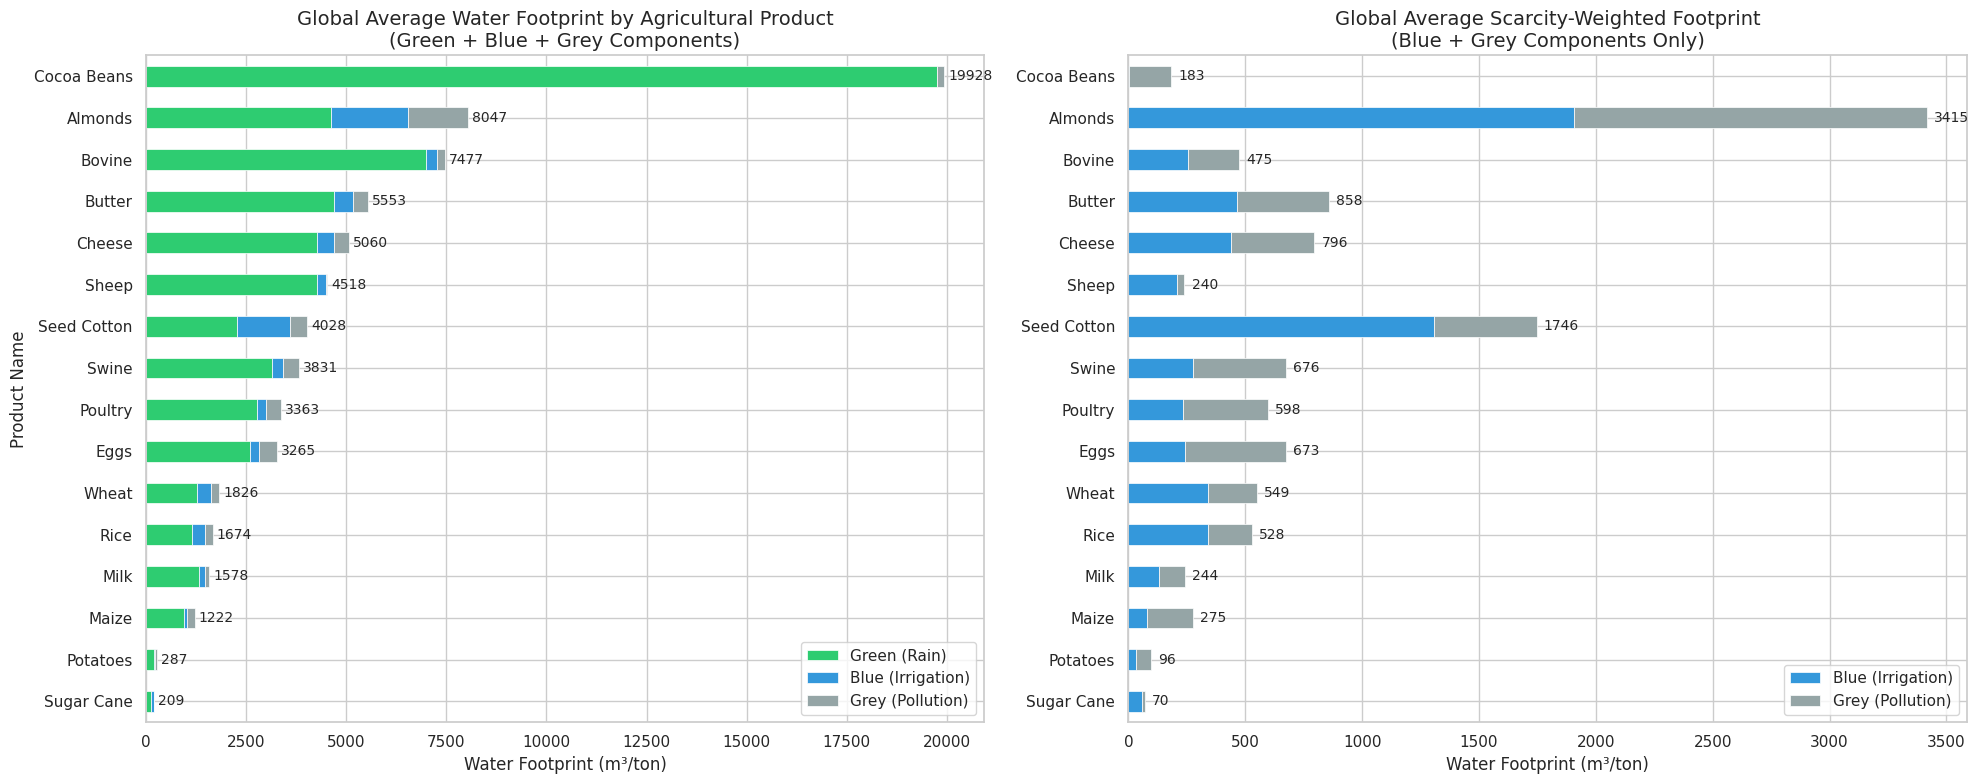


Key Insight: Cocoa beans and bovine meat have the highest WF per ton.
However, when removing green water, Almonds and Seed Cotton stand out as major consumers of scarce blue/grey water.


In [ ]:
# Build global averages from the original data sources
# Crops: use the 'Global average' column from crops_raw
crops_raw_fresh = pd.read_csv('crops_by_country.csv')
crops_raw_fresh['Product Name'] = crops_raw_fresh['Product Name'].ffill()
crops_raw_fresh['WF Type'] = ['Green', 'Blue', 'Grey'] * (len(crops_raw_fresh) // 3)
crop_name_map_full = {
    'Wheat': 'Wheat', 'Rice, paddy': 'Rice', 'Maize': 'Maize',
    'Potatoes': 'Potatoes', 'Sugar cane': 'Sugar Cane',
    'Almonds, with shell': 'Almonds', 'Seed cotton': 'Seed Cotton',
    'Cocoa beans': 'Cocoa Beans'
}
crops_raw_fresh['Product Name'] = crops_raw_fresh['Product Name'].map(crop_name_map_full)
global_crops = crops_raw_fresh.pivot_table(index='Product Name', columns='WF Type', values='Global average', aggfunc='first')

# Animals: use 'World Average' column from the weighted-average extraction
anim_raw_fresh = pd.read_csv('anim_by_country.csv')
# The "World Average" column was parsed as 'nan - Weighted average' due to missing ffill during extraction
wa_world = anim_raw_fresh['nan - Weighted average']
anim_names = anim_raw_fresh['Product Name'].ffill()
anim_name_map = {
    'Bov.animals,pure,breedng': 'Bovine', 'Swine,pure,for breeding': 'Swine',
    'Sheep, live': 'Sheep', 'Poultry, live,over 185g': 'Poultry',
    'Milk,cream unsweetened': 'Milk', 'butter': 'Butter',
    'Cheese, powdered, grated': 'Cheese', "Birds' eggs, in shell": 'Eggs'
}
anim_global = pd.DataFrame({
    'Product Name': anim_names.map(anim_name_map),
    'WF Type': ['Green', 'Blue', 'Grey'] * 8,
    'Global average': wa_world.values
})
global_anim = anim_global.pivot_table(index='Product Name', columns='WF Type', values='Global average', aggfunc='first')

# Combine
global_pivot = pd.concat([global_crops, global_anim])
global_pivot['Total'] = global_pivot['Green'] + global_pivot['Blue'] + global_pivot['Grey']
global_pivot['Blue_Grey_Total'] = global_pivot['Blue'] + global_pivot['Grey']
global_pivot = global_pivot.sort_values('Total', ascending=True)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Chart 1: All Components
global_pivot[['Green', 'Blue', 'Grey']].plot(
    kind='barh', stacked=True, ax=axes[0],
    color=['#2ecc71', '#3498db', '#95a5a6'],
    edgecolor='white', linewidth=0.5
)
axes[0].set_xlabel('Water Footprint (m³/ton)')
axes[0].set_title('Global Average Water Footprint by Agricultural Product\n(Green + Blue + Grey Components)')
axes[0].legend(['Green (Rain)', 'Blue (Irrigation)', 'Grey (Pollution)'], loc='lower right')

for i, (idx, row) in enumerate(global_pivot.iterrows()):
    axes[0].text(row['Total'] + 100, i, f"{row['Total']:.0f}", va='center', fontsize=10)

# Chart 2: Blue + Grey Only
global_pivot[['Blue', 'Grey']].plot(
    kind='barh', stacked=True, ax=axes[1],
    color=['#3498db', '#95a5a6'],
    edgecolor='white', linewidth=0.5
)
axes[1].set_xlabel('Water Footprint (m³/ton)')
axes[1].set_title('Global Average Scarcity-Weighted Footprint\n(Blue + Grey Components Only)')
axes[1].legend(['Blue (Irrigation)', 'Grey (Pollution)'], loc='lower right')
axes[1].set_ylabel('')

for i, (idx, row) in enumerate(global_pivot.iterrows()):
    axes[1].text(row['Blue_Grey_Total'] + 30, i, f"{row['Blue_Grey_Total']:.0f}", va='center', fontsize=10)

plt.tight_layout()
plt.savefig('chart01_global_avg_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Insight: Cocoa beans and bovine meat have the highest WF per ton.")
print("However, when removing green water, Almonds and Seed Cotton stand out as major consumers of scarce blue/grey water.")

### Chart 2: Water Footprint Composition — Green/Blue/Grey Shares

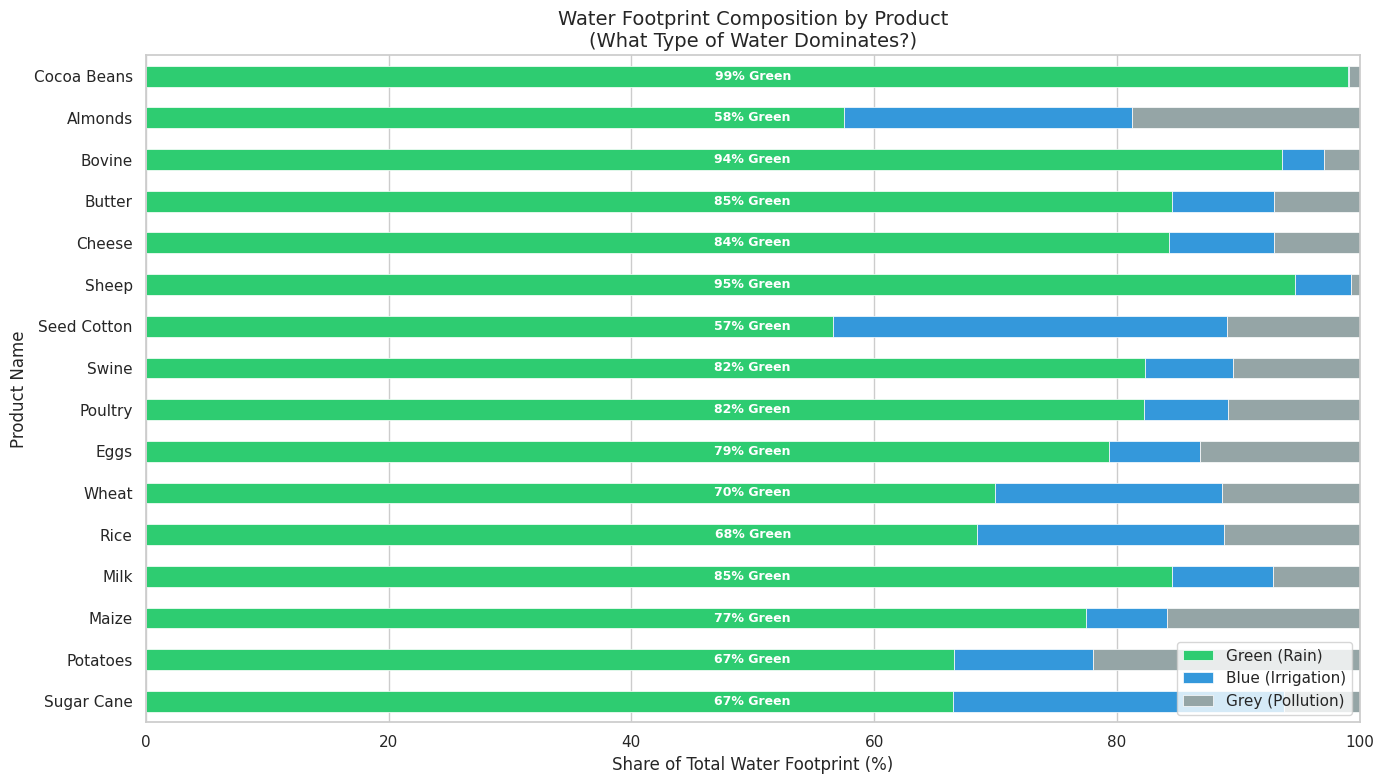


Key Insight: Cocoa (99% green) and Sugar Cane (67% green) are almost entirely rain-fed.
Seed Cotton and Almonds have the highest blue (irrigation) shares among crops.
Swine and Poultry have notably high grey (pollution) shares from feed production.


In [ ]:
# Percentage composition by product
global_pct = global_pivot[['Green', 'Blue', 'Grey']].div(global_pivot['Total'], axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 8))
global_pct.plot(
    kind='barh', stacked=True, ax=ax,
    color=['#2ecc71', '#3498db', '#95a5a6'],
    edgecolor='white', linewidth=0.5
)
ax.set_xlabel('Share of Total Water Footprint (%)')
ax.set_title('Water Footprint Composition by Product\n(What Type of Water Dominates?)')
ax.legend(['Green (Rain)', 'Blue (Irrigation)', 'Grey (Pollution)'], loc='lower right')
ax.set_xlim(0, 100)

for i, (idx, row) in enumerate(global_pct.iterrows()):
    # Show the dominant component percentage
    dominant = row.idxmax()
    ax.text(50, i, f"{row[dominant]:.0f}% {dominant}", va='center', ha='center',
            fontsize=9, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('chart02_composition.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Insight: Cocoa (99% green) and Sugar Cane (67% green) are almost entirely rain-fed.")
print("Seed Cotton and Almonds have the highest blue (irrigation) shares among crops.")
print("Swine and Poultry have notably high grey (pollution) shares from feed production.")

### Chart 3: Cross-Country Variability — How Much Does Efficiency Vary?

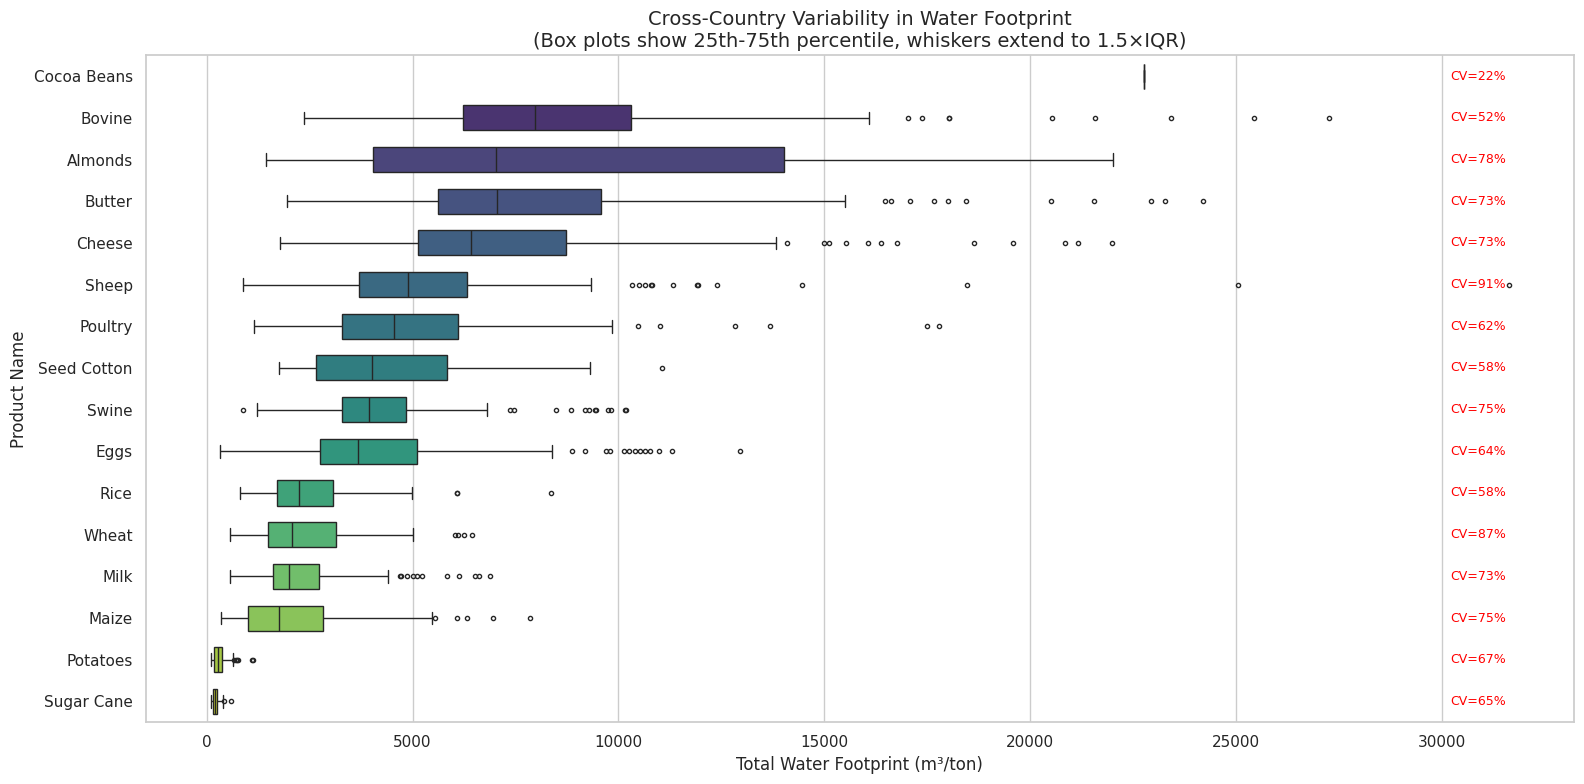


Key Insight: All products show >40% coefficient of variation across countries.
This means for the SAME product, some countries use 2-10× less water per ton.
The gap represents achievable efficiency gains through technology transfer and policy.


In [ ]:
# Box plot of total WF by product across countries
fig, ax = plt.subplots(figsize=(16, 8))

product_order = master.groupby('Product Name')['Total_WF'].median().sort_values(ascending=False).index

# Filter extreme outliers for visibility (keep < 99th percentile per product)
plot_data = master.copy()
for p in product_order:
    mask = plot_data['Product Name'] == p
    q99 = plot_data.loc[mask, 'Total_WF'].quantile(0.99)
    plot_data.loc[mask & (plot_data['Total_WF'] > q99), 'Total_WF'] = np.nan

sns.boxplot(data=plot_data, y='Product Name', x='Total_WF', order=product_order,
            ax=ax, palette='viridis', width=0.6, fliersize=3)
ax.set_xlabel('Total Water Footprint (m³/ton)')
ax.set_title('Cross-Country Variability in Water Footprint\n(Box plots show 25th-75th percentile, whiskers extend to 1.5×IQR)')

# Add CV annotation
for i, product in enumerate(product_order):
    d = master[master['Product Name'] == product]['Total_WF'].dropna()
    cv = d.std() / d.mean() * 100
    ax.text(ax.get_xlim()[1] * 0.95, i, f'CV={cv:.0f}%', va='center', ha='right', fontsize=9, color='red')

plt.tight_layout()
plt.savefig('chart03_variability_box.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Insight: All products show >40% coefficient of variation across countries.")
print("This means for the SAME product, some countries use 2-10× less water per ton.")
print("The gap represents achievable efficiency gains through technology transfer and policy.")

### Chart 4: Regional Heatmap — Median Water Footprint by Region and Product

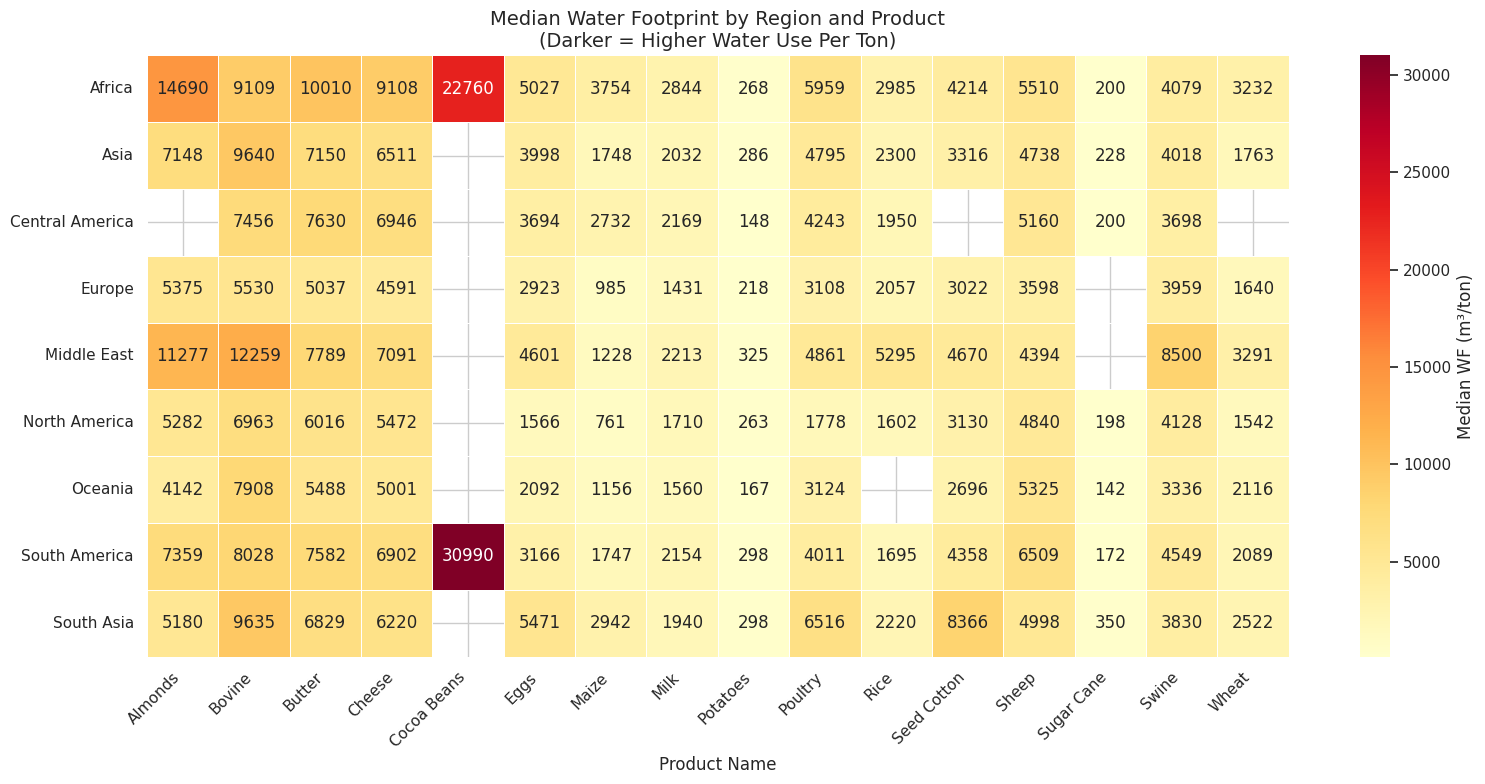


Key Insight: The Middle East and Africa show the highest WF for most products,
reflecting arid climates requiring more irrigation (blue) and often lower yields.
Europe and North America tend toward lower WF, reflecting higher agricultural efficiency.


In [ ]:
# Regional heatmap
region_product_wf = master.groupby(['Region', 'Product Name'])['Total_WF'].median().unstack()
region_product_wf = region_product_wf.drop('Other', errors='ignore').drop('Global', errors='ignore')

# Only keep regions with enough data
region_counts = master.groupby('Region')['Country'].nunique()
valid_regions = region_counts[region_counts >= 3].index
region_product_wf = region_product_wf.loc[region_product_wf.index.isin(valid_regions)]
region_product_wf = region_product_wf.dropna(axis=1, how='all')

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(region_product_wf, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Median WF (m³/ton)'})
ax.set_title('Median Water Footprint by Region and Product\n(Darker = Higher Water Use Per Ton)')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart04_regional_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Insight: The Middle East and Africa show the highest WF for most products,")
print("reflecting arid climates requiring more irrigation (blue) and often lower yields.")
print("Europe and North America tend toward lower WF, reflecting higher agricultural efficiency.")

### Chart 5: Top 10 Most & Least Water-Efficient Countries per Product

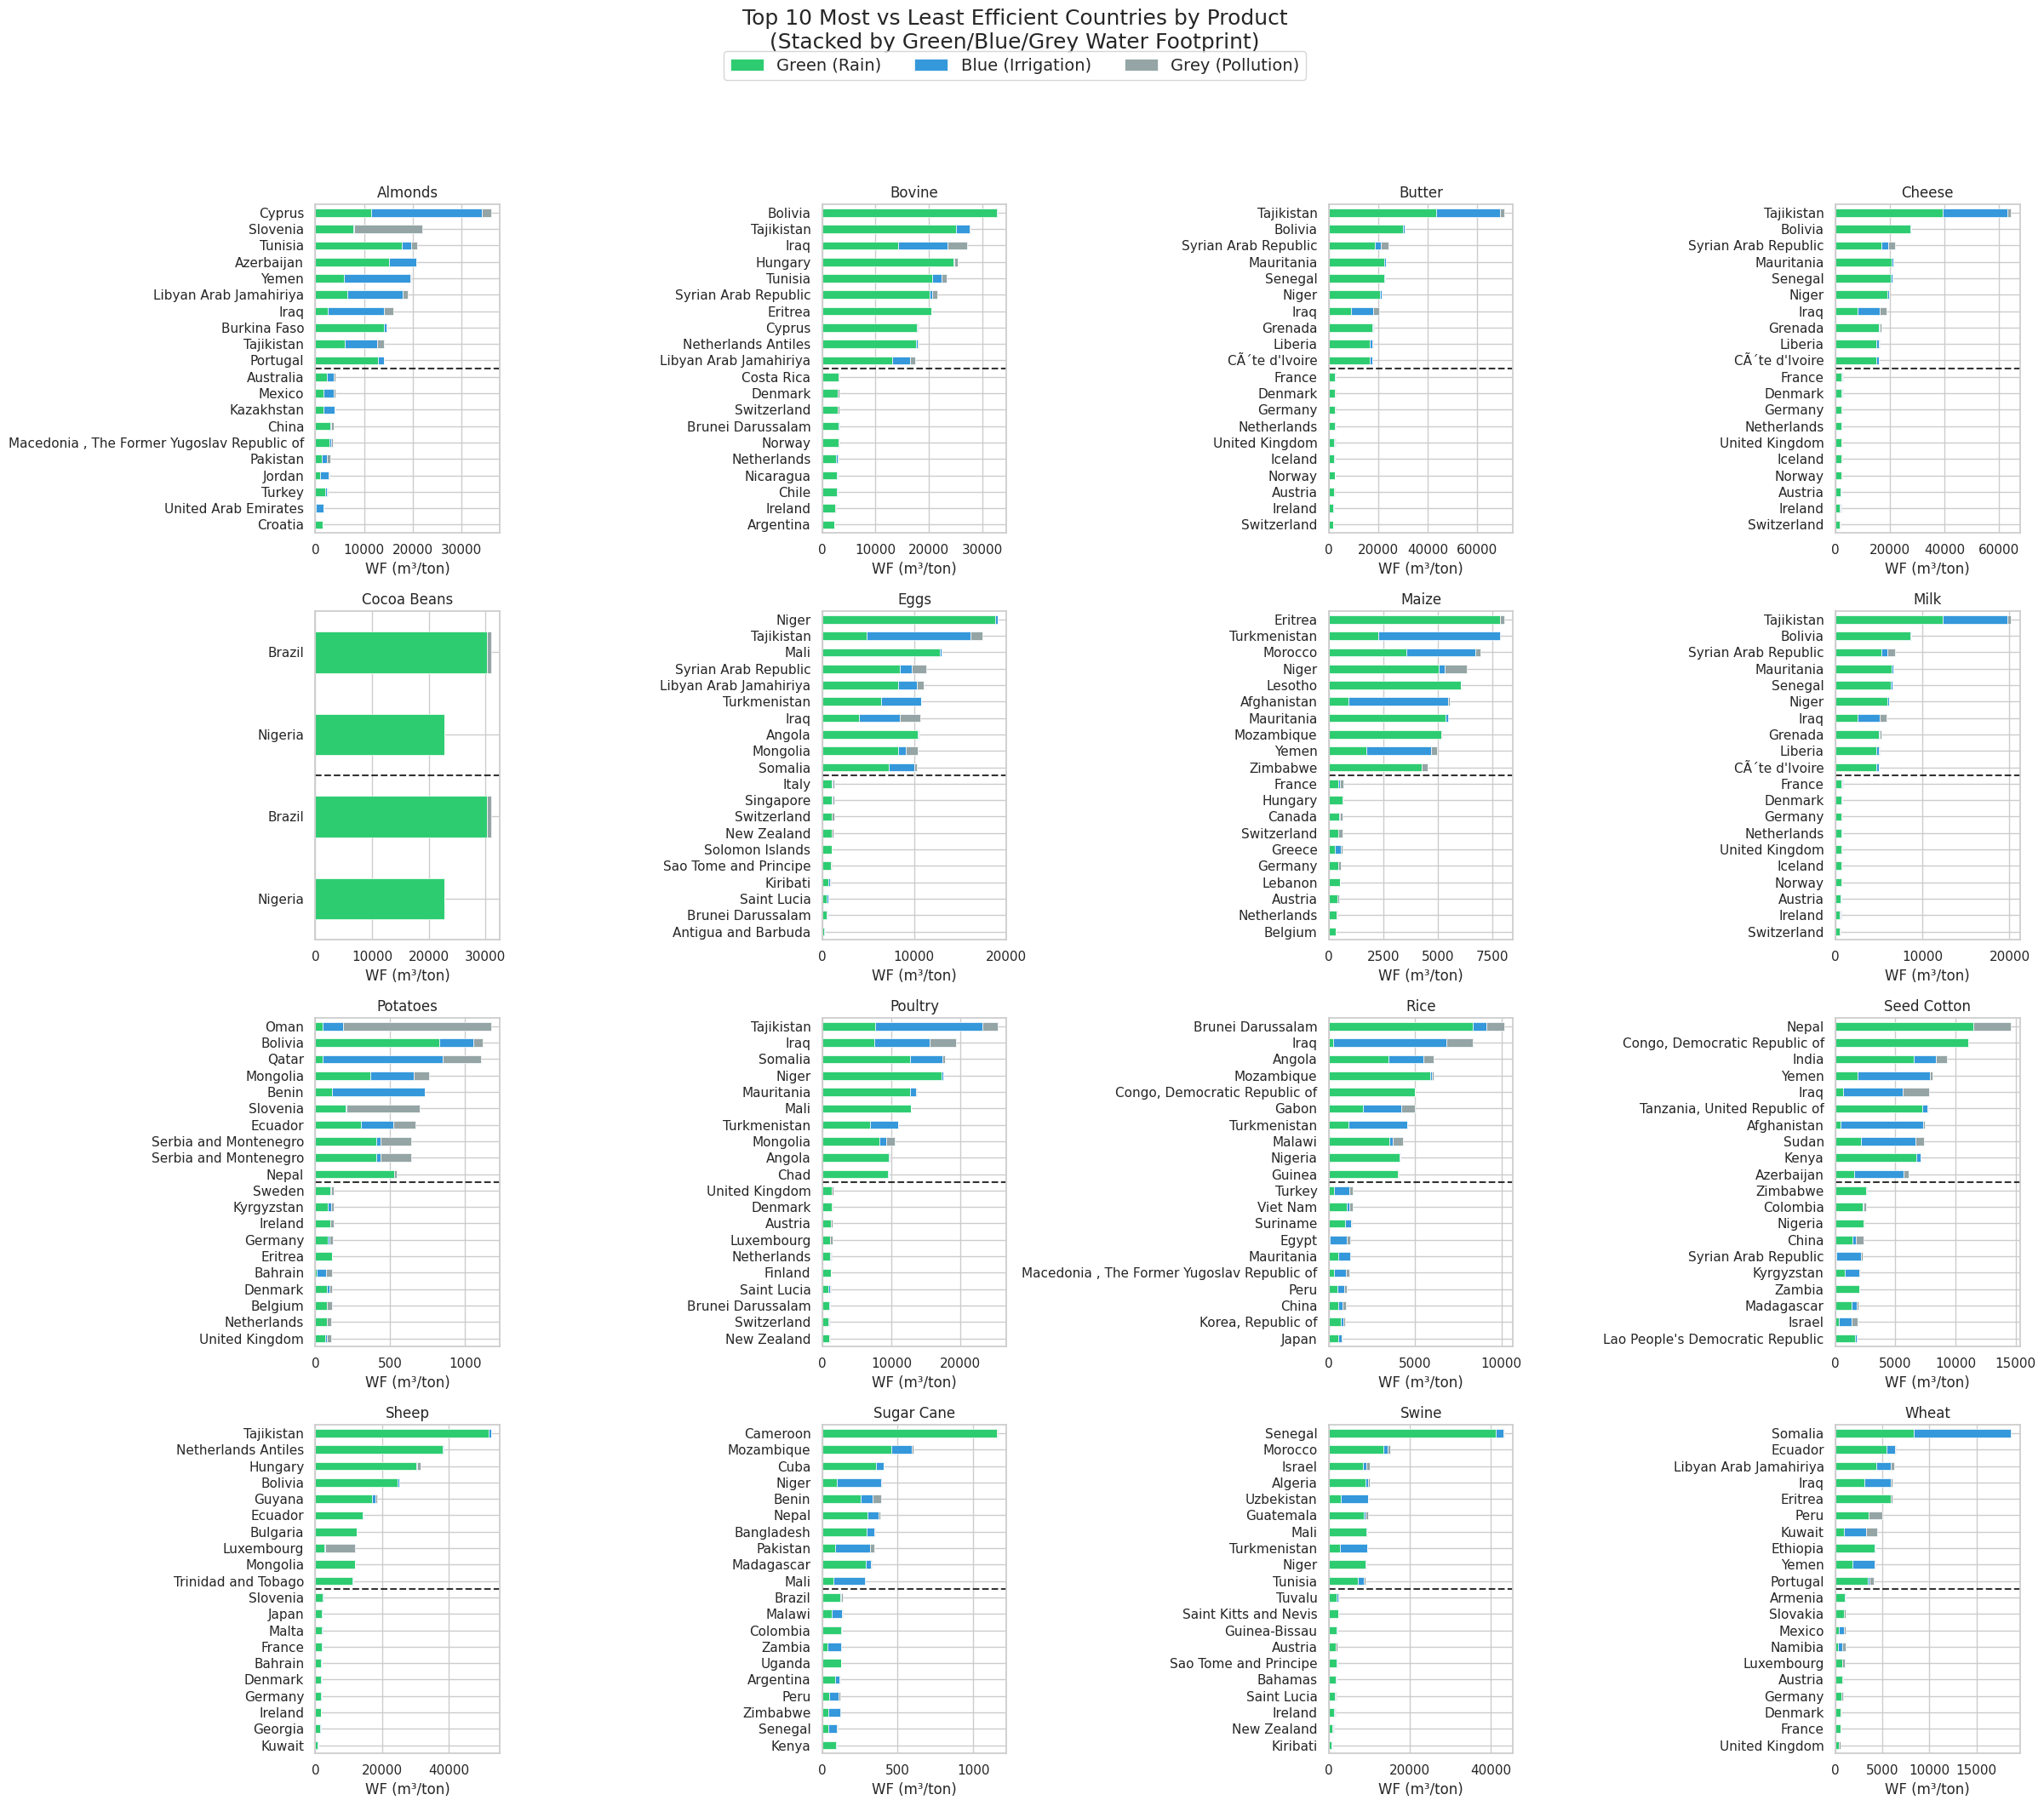


Key Insight: By stacking the green, blue, and grey components, we can see if the least efficient
producers are driving up their footprint due to high reliance on irrigation (blue), high pollution (grey),
or simply large rainfall requirements (green) relative to crop yield.


In [ ]:
# Show top 10 most efficient and bottom 10 least efficient for all 16 products
all_products = sorted(master['Product Name'].dropna().unique())

# Create a 4x4 grid for the 16 products
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(24, 20))
axes = axes.flatten()

for i, product in enumerate(all_products):
    ax = axes[i]
    prod_data = master[(master['Product Name'] == product) & (master['Total_WF'] > 0)].copy()
    prod_data = prod_data.dropna(subset=['Total_WF']).sort_values('Total_WF')

    if len(prod_data) == 0:
        continue

    # Top 10 most efficient (lowest WF)
    top10 = prod_data.head(10)
    # Bottom 10 least efficient (highest WF)
    bottom10 = prod_data.tail(10)

    combined = pd.concat([top10, bottom10])

    # Plot stacked horizontal bars
    combined.set_index('Country')[['Green_WF', 'Blue_WF', 'Grey_WF']].plot(
        kind='barh', stacked=True, ax=ax,
        color=['#2ecc71', '#3498db', '#95a5a6'],
        edgecolor='white', linewidth=0.5, legend=False
    )

    ax.set_xlabel('WF (m³/ton)')
    ax.set_ylabel('')
    ax.set_title(f'{product}', fontsize=12)

    # Add a horizontal line to separate top 10 and bottom 10
    ax.axhline(y=len(top10) - 0.5, color='black', linestyle='--', alpha=0.8)

# Add a common legend for the entire figure
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, ['Green (Rain)', 'Blue (Irrigation)', 'Grey (Pollution)'], loc='upper center', ncol=3, fontsize=14, bbox_to_anchor=(0.5, 1.04))

plt.suptitle('Top 10 Most vs Least Efficient Countries by Product\n(Stacked by Green/Blue/Grey Water Footprint)', fontsize=18, y=1.06)
plt.tight_layout()
plt.savefig('chart05_efficiency_rankings_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Insight: By stacking the green, blue, and grey components, we can see if the least efficient")
print("producers are driving up their footprint due to high reliance on irrigation (blue), high pollution (grey),")
print("or simply large rainfall requirements (green) relative to crop yield.")

### Chart 6: Green vs Blue Water Tradeoff Scatter

NameError: name 'master' is not defined

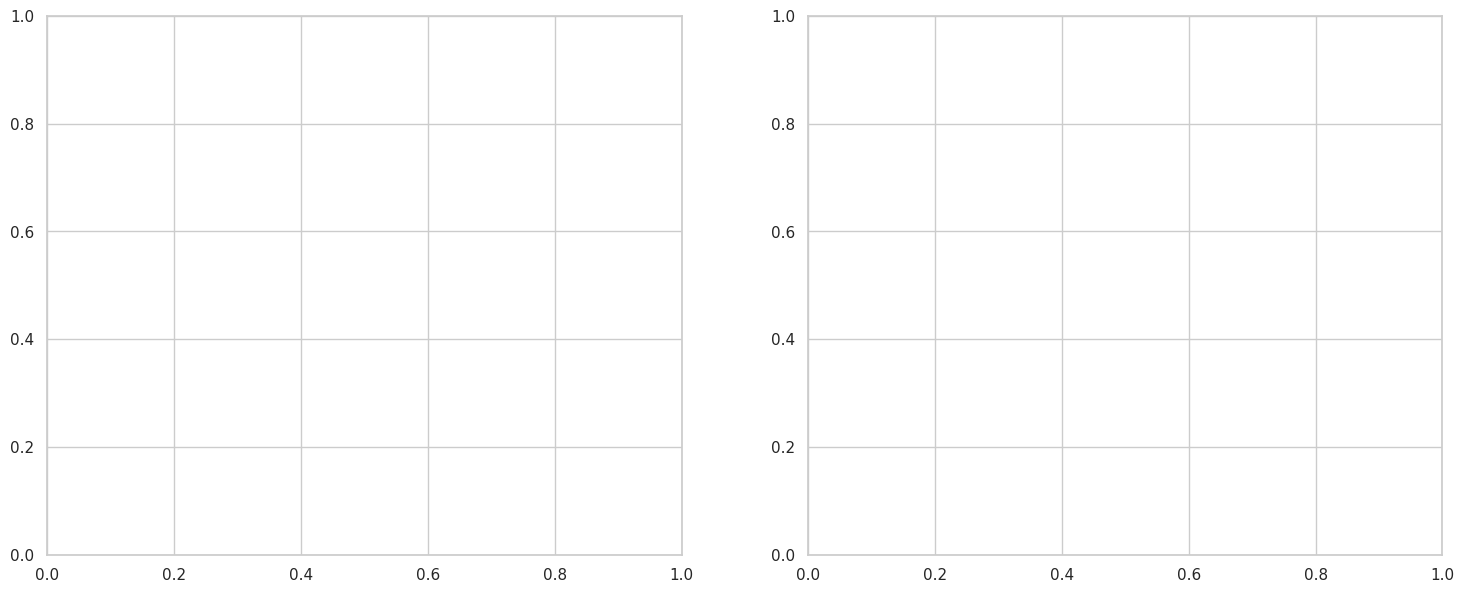

In [ ]:
# Green vs Blue scatter — reveals climate vs irrigation tradeoff
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Crops
crop_data = master[master['Category'] == 'Crop'].dropna(subset=['Green_pct', 'Blue_pct', 'Grey_pct'])
crop_products = crop_data['Product Name'].unique()
crop_colors = sns.color_palette("husl", len(crop_products))

for i, product in enumerate(crop_products):
    d = crop_data[crop_data['Product Name'] == product]
    axes[0].scatter(d['Green_pct'], d['Blue_pct'], label=product, alpha=0.8, s=50, color=crop_colors[i], edgecolor='w', linewidth=0.5)

    # Label outliers: Very high blue or very high grey (low green+blue)
    outliers = d[(d['Blue_pct'] > 85) | (d['Grey_pct'] > 40)]
    for _, row in outliers.iterrows():
        axes[0].annotate(row['Country'][:12], (row['Green_pct']+1, row['Blue_pct']+1), fontsize=8, alpha=0.8)

axes[0].set_xlabel('Green WF Share (%)')
axes[0].set_ylabel('Blue WF Share (%)')
axes[0].set_title('Crops: Green vs Blue Tradeoff')
axes[0].legend(fontsize=9, loc='upper right')
axes[0].plot([0, 100], [100, 0], 'k--', alpha=0.3, label='0% Grey Line (Perfect tradeoff)')

# Animals
anim_data = master[master['Category'].isin(['Animal', 'Animal Product'])].dropna(subset=['Green_pct', 'Blue_pct', 'Grey_pct'])
anim_products = anim_data['Product Name'].unique()
anim_colors = sns.color_palette("Set1", len(anim_products))

for i, product in enumerate(anim_products):
    d = anim_data[anim_data['Product Name'] == product]
    axes[1].scatter(d['Green_pct'], d['Blue_pct'], label=product, alpha=0.8, s=50, color=anim_colors[i], edgecolor='w', linewidth=0.5)

    # Label outliers
    outliers = d[(d['Blue_pct'] > 40) | (d['Grey_pct'] > 35)]
    for _, row in outliers.iterrows():
        axes[1].annotate(row['Country'][:12], (row['Green_pct']+1, row['Blue_pct']+1), fontsize=8, alpha=0.8)

axes[1].set_xlabel('Green WF Share (%)')
axes[1].set_ylabel('Blue WF Share (%)')
axes[1].set_title('Animals: Green vs Blue Tradeoff')
axes[1].legend(fontsize=9, loc='upper right')
axes[1].plot([0, 100], [100, 0], 'k--', alpha=0.3)

plt.suptitle('Green-Blue Tradeoff: Climate Advantage vs Irrigation Dependence\n(Distinct Colors by Product & Outliers Labeled)', fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig('chart06_green_blue_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Insight: A clear inverse relationship — countries with high green % have low blue %.")
print("This confirms that irrigation substitutes for rainfall: arid countries trade blue for green.")
print("Points near the upper-left (high green, low blue) represent climate-advantaged producers.")
print("Labeled countries are outliers with unusually high irrigation dependence (blue) or high pollution (grey) shares.")

### Chart 7: Production-Weighted Water Consumption — Which Countries Matter Most?

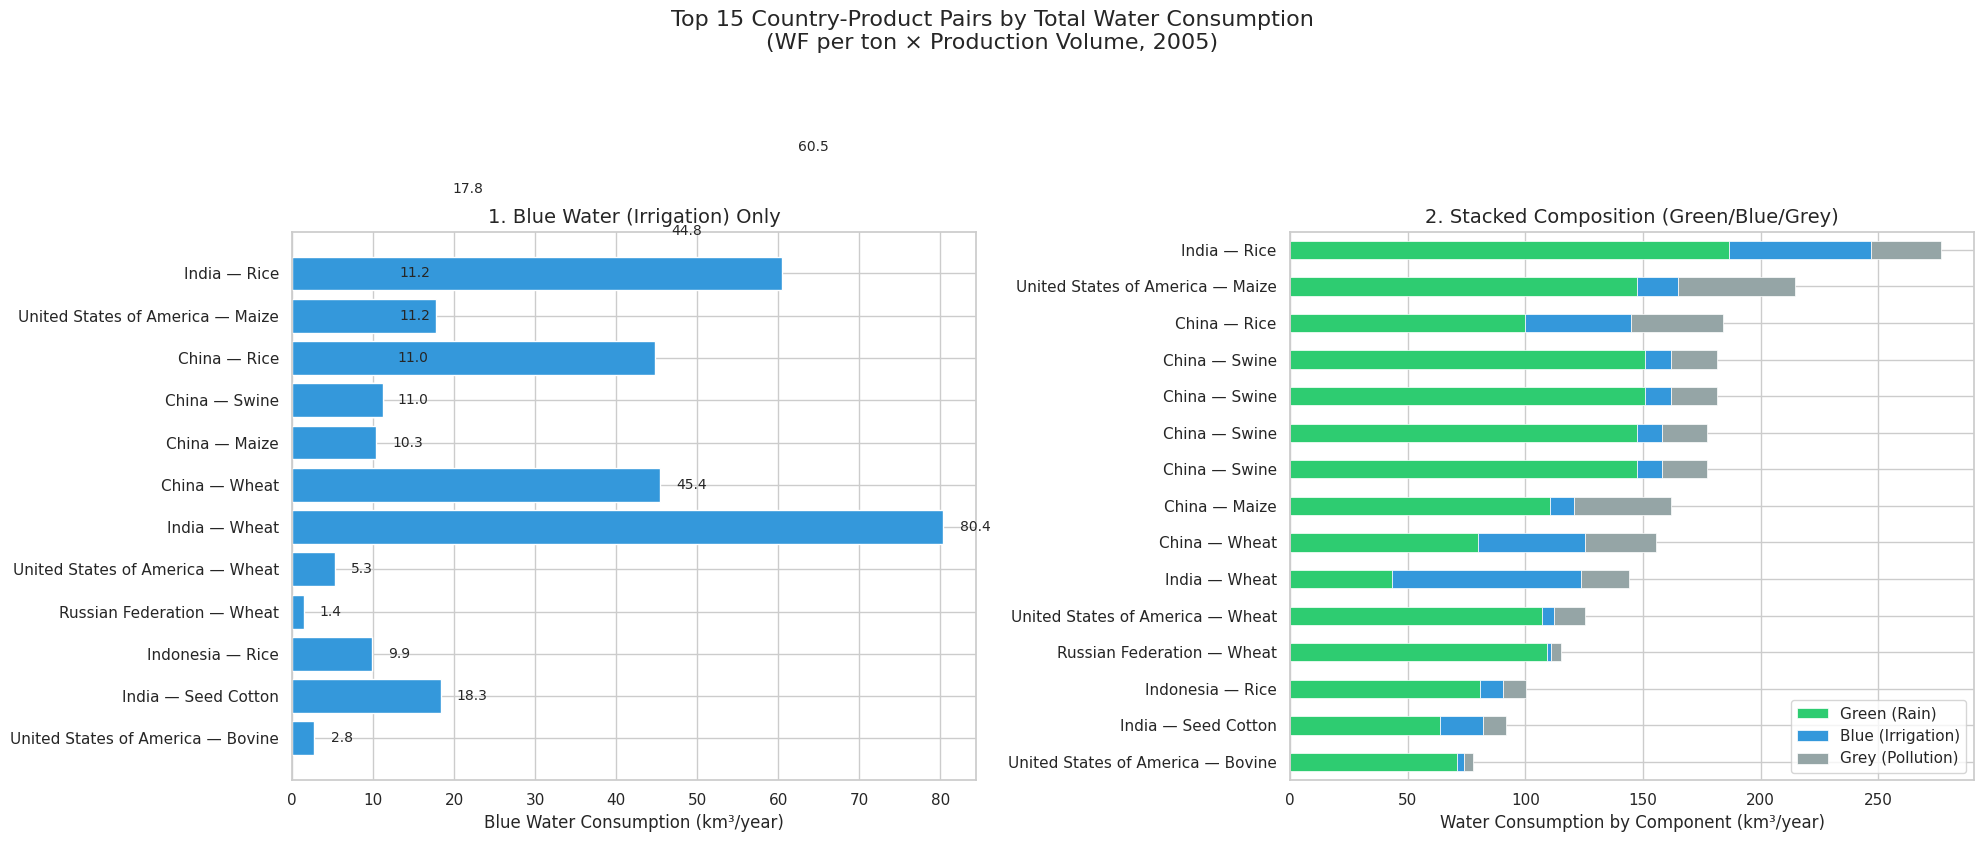


Key Insight: Production volume dramatically changes the picture.
India's wheat and rice, China's rice, and Brazil's bovine are the largest
absolute water consumers — these are the highest-leverage policy targets.
A small efficiency improvement in these country-product pairs saves more water
than eliminating production in dozens of smaller producers.


In [ ]:
# Production-weighted analysis: Total water consumed = WF × production
# This answers "where is the most water actually being used?"
prod_weighted = master.dropna(subset=['Production_2005_t', 'Total_WF', 'Green_WF', 'Blue_WF', 'Grey_WF']).copy()
prod_weighted = prod_weighted[prod_weighted['Production_2005_t'] > 0]

# Calculate volumes for all components
prod_weighted['Total_Water_Vol_2005'] = prod_weighted['Total_WF'] * prod_weighted['Production_2005_t']
prod_weighted['Green_Water_Vol_2005'] = prod_weighted['Green_WF'] * prod_weighted['Production_2005_t']
prod_weighted['Blue_Water_Vol_2005'] = prod_weighted['Blue_WF'] * prod_weighted['Production_2005_t']
prod_weighted['Grey_Water_Vol_2005'] = prod_weighted['Grey_WF'] * prod_weighted['Production_2005_t']

# Top 15 country-product pairs by total water volume
keep_cols = ['Country', 'Product Name', 'Total_WF', 'Production_2005_t',
             'Total_Water_Vol_2005', 'Green_Water_Vol_2005', 'Blue_Water_Vol_2005', 'Grey_Water_Vol_2005']
top_water_users = prod_weighted.nlargest(15, 'Total_Water_Vol_2005')[keep_cols].copy()

# Convert to km³
top_water_users['Water_km3'] = top_water_users['Total_Water_Vol_2005'] / 1e9
top_water_users['Green_km3'] = top_water_users['Green_Water_Vol_2005'] / 1e9
top_water_users['Blue_km3'] = top_water_users['Blue_Water_Vol_2005'] / 1e9
top_water_users['Grey_km3'] = top_water_users['Grey_Water_Vol_2005'] / 1e9
top_water_users['Label'] = top_water_users['Country'] + ' — ' + top_water_users['Product Name']

# Sort ascending so the largest is at the top of the horizontal bar charts
top_water_users = top_water_users.sort_values('Water_km3', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Chart 1: Blue Water Only
axes[0].barh(top_water_users['Label'], top_water_users['Blue_km3'], color='#3498db', edgecolor='white')
axes[0].set_xlabel('Blue Water Consumption (km³/year)')
axes[0].set_title('1. Blue Water (Irrigation) Only')
for i, (_, row) in enumerate(top_water_users.iterrows()):
    axes[0].text(row['Blue_km3'] + 2, i, f"{row['Blue_km3']:.1f}", va='center', fontsize=10)

# Chart 2: Stacked Components
top_water_users.set_index('Label')[['Green_km3', 'Blue_km3', 'Grey_km3']].plot(
    kind='barh', stacked=True, ax=axes[1],
    color=['#2ecc71', '#3498db', '#95a5a6'],
    edgecolor='white', linewidth=0.5
)
axes[1].set_xlabel('Water Consumption by Component (km³/year)')
axes[1].set_title('2. Stacked Composition (Green/Blue/Grey)')
axes[1].legend(['Green (Rain)', 'Blue (Irrigation)', 'Grey (Pollution)'], loc='lower right')
axes[1].set_ylabel('')

plt.suptitle('Top 15 Country-Product Pairs by Total Water Consumption\n(WF per ton × Production Volume, 2005)', fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig('chart07_production_weighted.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Insight: Production volume dramatically changes the picture.")
print("India's wheat and rice, China's rice, and Brazil's bovine are the largest")
print("absolute water consumers — these are the highest-leverage policy targets.")
print("A small efficiency improvement in these country-product pairs saves more water")
print("than eliminating production in dozens of smaller producers.")

### Chart 8: Ternary Composition Plot — Green-Blue-Grey Profiles by Region

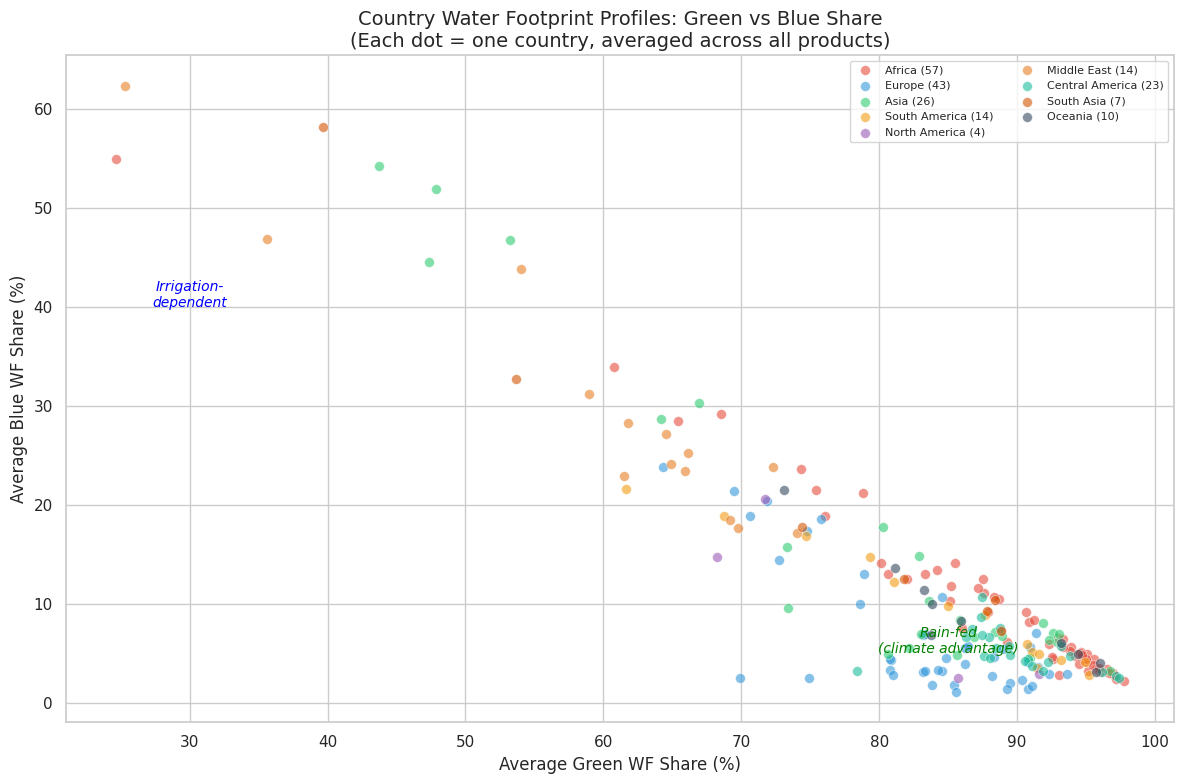


Key Insight: Middle East countries cluster in the high-blue (irrigation) zone.
African and South American countries spread across the green-dominant zone.
European countries cluster in moderate green with higher grey (pollution from fertilizers).


In [ ]:
# Ternary-style plot using 2D projection of the 3-component composition
# Since Green% + Blue% + Grey% ≈ 100%, we plot Green% vs Blue% and color by region
fig, ax = plt.subplots(figsize=(12, 8))

region_colors = {
    'Africa': '#e74c3c', 'Europe': '#3498db', 'Asia': '#2ecc71',
    'South America': '#f39c12', 'North America': '#9b59b6',
    'Middle East': '#e67e22', 'Central America': '#1abc9c',
    'South Asia': '#d35400', 'Oceania': '#34495e'
}

country_avg = master.groupby(['Country', 'Region']).agg(
    Green_pct=('Green_pct', 'mean'),
    Blue_pct=('Blue_pct', 'mean'),
    Grey_pct=('Grey_pct', 'mean')
).reset_index()
country_avg = country_avg[country_avg['Region'] != 'Other']

for region, color in region_colors.items():
    d = country_avg[country_avg['Region'] == region]
    if len(d) > 0:
        ax.scatter(d['Green_pct'], d['Blue_pct'], c=color, label=f'{region} ({len(d)})',
                   alpha=0.6, s=50, edgecolor='white', linewidth=0.5)

ax.set_xlabel('Average Green WF Share (%)')
ax.set_ylabel('Average Blue WF Share (%)')
ax.set_title('Country Water Footprint Profiles: Green vs Blue Share\n(Each dot = one country, averaged across all products)')
ax.legend(fontsize=8, loc='upper right', ncol=2)

# Add annotation arrows for key observations
ax.annotate('Rain-fed\n(climate advantage)', xy=(85, 5), fontsize=10, color='green',
            ha='center', style='italic')
ax.annotate('Irrigation-\ndependent', xy=(30, 40), fontsize=10, color='blue',
            ha='center', style='italic')

plt.tight_layout()
plt.savefig('chart08_ternary_composition.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Insight: Middle East countries cluster in the high-blue (irrigation) zone.")
print("African and South American countries spread across the green-dominant zone.")
print("European countries cluster in moderate green with higher grey (pollution from fertilizers).")

## Statistical Analysis

### Efficiency Rankings — Which Countries Lead?

In [ ]:
# Composite efficiency score: rank each country per product, then average ranks
rankings = []
for product in master['Product Name'].unique():
    prod_data = master[master['Product Name'] == product].dropna(subset=['Total_WF'])
    prod_data = prod_data[prod_data['Total_WF'] > 0].copy()
    prod_data['Rank'] = prod_data['Total_WF'].rank(method='min')
    prod_data['Percentile'] = prod_data['Total_WF'].rank(pct=True) * 100
    rankings.append(prod_data[['Country', 'Product Name', 'Total_WF', 'Rank', 'Percentile']])

all_rankings = pd.concat(rankings)

# Countries that appear in at least 8 products → composite score
country_scores = all_rankings.groupby('Country').agg(
    avg_percentile=('Percentile', 'mean'),
    n_products=('Product Name', 'nunique'),
    median_wf=('Total_WF', 'median')
).sort_values('avg_percentile')

# Show top 15 most efficient (lowest percentile = best)
top_efficient = country_scores[country_scores['n_products'] >= 8].head(15)
print("Top 15 Most Water-Efficient Countries (across 8+ products):")
print("(Lower avg percentile = consistently lower WF per ton)")
print(top_efficient.round(1).to_string())

print("\n" + "=" * 70)
bottom_efficient = country_scores[country_scores['n_products'] >= 8].tail(15)
print("\nBottom 15 Least Water-Efficient Countries (across 8+ products):")
print(bottom_efficient.round(1).to_string())

Top 15 Most Water-Efficient Countries (across 8+ products):
(Lower avg percentile = consistently lower WF per ton)
                avg_percentile  n_products  median_wf
Country                                              
Ireland                    3.7           9     1800.0
Switzerland                5.3          10     1548.0
Germany                    6.0          11     1834.0
United Kingdom             6.0          10     2098.5
Netherlands                6.2          10     2003.5
Denmark                    6.2          10     1746.5
Austria                    6.8          11     1550.0
New Zealand                6.9           9     1212.0
France                     8.5          11     1893.0
Sweden                     9.3           9     2468.0
Norway                     9.7           9     2404.0
Iceland                   10.5           8     2528.0
Finland                   12.7           9     2816.0
Belgium                   12.7          10     2635.5
Bahrain              

### Regional Kruskal-Wallis Test — Do Regions Differ Significantly?

In [ ]:
# Kruskal-Wallis test: do regions have statistically different water footprints?
print("Kruskal-Wallis H-test: Regional differences in water footprint")
print("=" * 70)
print(f"{'Product':<15} {'H-statistic':>12} {'p-value':>12} {'Significant':>12} {'Groups':>8}")
print("-" * 70)

test_products = ['Wheat', 'Rice', 'Maize', 'Potatoes', 'Bovine', 'Milk', 'Poultry', 'Eggs']

for product in test_products:
    prod_data = master[(master['Product Name'] == product) &
                       (master['Region'] != 'Other') &
                       (master['Region'] != 'Global')].dropna(subset=['Total_WF'])

    groups = [g['Total_WF'].values for _, g in prod_data.groupby('Region') if len(g) >= 3]

    if len(groups) >= 2:
        h_stat, p_val = kruskal(*groups)
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        print(f"{product:<15} {h_stat:>12.2f} {p_val:>12.4f} {sig:>12} {len(groups):>8}")

        # Report sample sizes per group
        if p_val < 0.05:
            group_sizes = prod_data.groupby('Region').size()
            valid_groups = group_sizes[group_sizes >= 3]

print("\nSignificance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")
print("Groups column shows number of regions with ≥3 countries producing this product.")
print("\nConclusion: Regions differ significantly in WF for most products, confirming")
print("that geography/climate systematically affects water efficiency.")

Kruskal-Wallis H-test: Regional differences in water footprint
Product          H-statistic      p-value  Significant   Groups
----------------------------------------------------------------------
Wheat                  23.68       0.0006          ***        7
Rice                   14.74       0.0115            *        6
Maize                  50.34       0.0000          ***        8
Potatoes                8.57       0.1994           ns        7
Bovine                 45.37       0.0000          ***        9
Milk                   66.32       0.0000          ***        9
Poultry                63.27       0.0000          ***        9
Eggs                   51.01       0.0000          ***        9

Significance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant
Groups column shows number of regions with ≥3 countries producing this product.

Conclusion: Regions differ significantly in WF for most products, confirming
that geography/climate systematically affects water efficiency

### Bovine Production System Deep Dive

Water Footprint by Animal and Production System (m³/ton):
                    median_total  median_bg  mean_green_pct  mean_blue_pct  mean_grey_pct  n_countries
Animal  System                                                                                        
Bovine  Grazing          11965.5      124.0            96.5            2.2            1.3          179
        Industrial        4086.0      305.0            89.7            6.2            4.1          194
        Mixed             7788.0      176.0            94.9            3.3            1.8          192
Poultry Grazing           7398.5      716.5            85.4            7.6            7.0          187
        Industrial        2827.5      283.5            85.5            7.5            7.0          197
        Mixed             4599.0      446.0            85.5            7.5            7.0          194
Sheep   Grazing           7259.0      182.0            97.1            2.7            0.2          143
        Industr

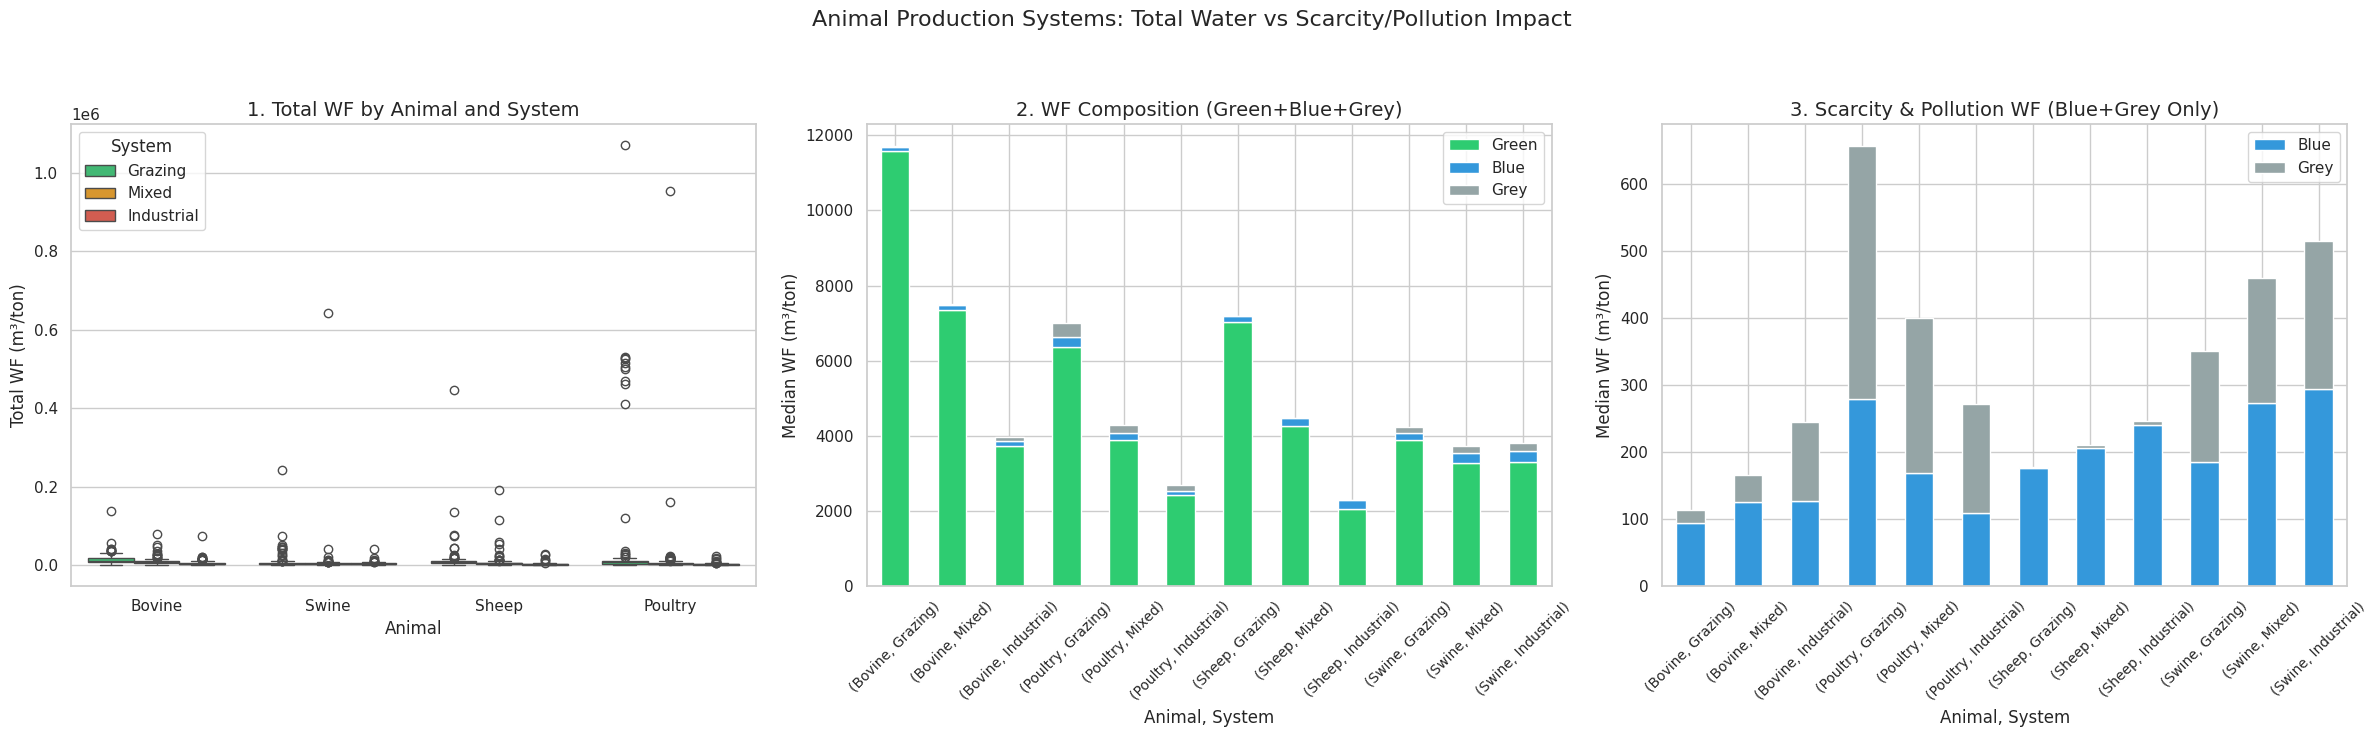


Key Insight: Across most animals, Grazing requires the most total water (mostly Green),
while Industrial systems shift the footprint toward Blue and Grey water.
Chart 3 isolates Blue and Grey water, clearly showing that Industrial and Mixed
systems consume more scarce/polluting water per ton than Grazing systems.


In [ ]:
# Extract grazing/mixed/industrial data for all 4 meat animals directly from raw data
a_raw = pd.read_csv('AnimalData.csv', header=None, nrows=5, encoding='latin1')
country_row = a_raw.iloc[2].ffill()
system_row = a_raw.iloc[3].str.strip()

# Read main data
df_a = pd.read_csv('AnimalData.csv', header=None, skiprows=4, encoding='latin1')
df_a[1] = df_a[1].astype(str).str.strip().str.replace(r"^'", '', regex=True)

sitc_map = {'00111': 'Bovine', '00131': 'Swine', '00121': 'Sheep', '00149': 'Poultry'}
animal_systems = []

for sitc, animal_name in sitc_map.items():
    if sitc not in df_a[1].values:
        continue
    idx = df_a[df_a[1] == sitc].index[0]
    # We need rows idx, idx+1, idx+2 (Green, Blue, Grey)
    data = df_a.iloc[idx:idx+3]

    for system in ['Grazing', 'Mixed', 'Industrial']:
        sys_cols = [i for i, v in enumerate(system_row) if str(v) == system]
        countries = [str(country_row.iloc[i]) for i in sys_cols]

        green_vals = pd.to_numeric(data.iloc[0, sys_cols].astype(str).str.replace(r"^'", '', regex=True), errors='coerce').values
        blue_vals = pd.to_numeric(data.iloc[1, sys_cols].astype(str).str.replace(r"^'", '', regex=True), errors='coerce').values
        grey_vals = pd.to_numeric(data.iloc[2, sys_cols].astype(str).str.replace(r"^'", '', regex=True), errors='coerce').values

        df = pd.DataFrame({
            'Country': countries,
            'Green_WF': green_vals,
            'Blue_WF': blue_vals,
            'Grey_WF': grey_vals,
            'System': system,
            'Animal': animal_name
        })
        df['Total_WF'] = df['Green_WF'] + df['Blue_WF'] + df['Grey_WF']
        df['Blue_Grey_WF'] = df['Blue_WF'] + df['Grey_WF']
        df = df[(df['Total_WF'] > 0) & df['Total_WF'].notna()]
        animal_systems.append(df)

all_sys = pd.concat(animal_systems, ignore_index=True)

# Summary statistics
print("Water Footprint by Animal and Production System (m³/ton):")
print("=" * 75)
summary = all_sys.groupby(['Animal', 'System']).agg(
    median_total=('Total_WF', 'median'),
    median_bg=('Blue_Grey_WF', 'median'),
    mean_green_pct=('Green_WF', lambda x: (x / all_sys.loc[x.index, 'Total_WF'] * 100).mean()),
    mean_blue_pct=('Blue_WF', lambda x: (x / all_sys.loc[x.index, 'Total_WF'] * 100).mean()),
    mean_grey_pct=('Grey_WF', lambda x: (x / all_sys.loc[x.index, 'Total_WF'] * 100).mean()),
    n_countries=('Country', 'nunique')
).round(1)
print(summary.to_string())

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# 1. Box plot
sns.boxplot(data=all_sys, x='Animal', y='Total_WF', hue='System', ax=axes[0],
            palette=['#2ecc71', '#f39c12', '#e74c3c'],
            hue_order=['Grazing', 'Mixed', 'Industrial'])
axes[0].set_ylabel('Total WF (m³/ton)')
axes[0].set_title('1. Total WF by Animal and System')

# Data for bar charts
sys_comp = all_sys.groupby(['Animal', 'System'])[['Green_WF', 'Blue_WF', 'Grey_WF']].median()
# Reorder index to group nicely
sys_comp = sys_comp.reindex(['Grazing', 'Mixed', 'Industrial'], level=1)

# 2. Stacked bar (All components)
sys_comp.plot(kind='bar', stacked=True, ax=axes[1],
              color=['#2ecc71', '#3498db', '#95a5a6'], edgecolor='white')
axes[1].set_ylabel('Median WF (m³/ton)')
axes[1].set_title('2. WF Composition (Green+Blue+Grey)')
axes[1].legend(['Green', 'Blue', 'Grey'])
axes[1].tick_params(axis='x', rotation=45, labelsize=10)
axes[1].set_xlabel('Animal, System')

# 3. Stacked bar (Blue + Grey only)
sys_comp[['Blue_WF', 'Grey_WF']].plot(kind='bar', stacked=True, ax=axes[2],
                                      color=['#3498db', '#95a5a6'], edgecolor='white')
axes[2].set_ylabel('Median WF (m³/ton)')
axes[2].set_title('3. Scarcity & Pollution WF (Blue+Grey Only)')
axes[2].legend(['Blue', 'Grey'])
axes[2].tick_params(axis='x', rotation=45, labelsize=10)
axes[2].set_xlabel('Animal, System')

plt.suptitle('Animal Production Systems: Total Water vs Scarcity/Pollution Impact', fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig('chart09_animal_systems.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Insight: Across most animals, Grazing requires the most total water (mostly Green),")
print("while Industrial systems shift the footprint toward Blue and Grey water.")
print("Chart 3 isolates Blue and Grey water, clearly showing that Industrial and Mixed")
print("systems consume more scarce/polluting water per ton than Grazing systems.")

## Machine Learning Analysis

### K-Means Clustering: Country Water Footprint Profiles

Countries with ≥4 products: 202


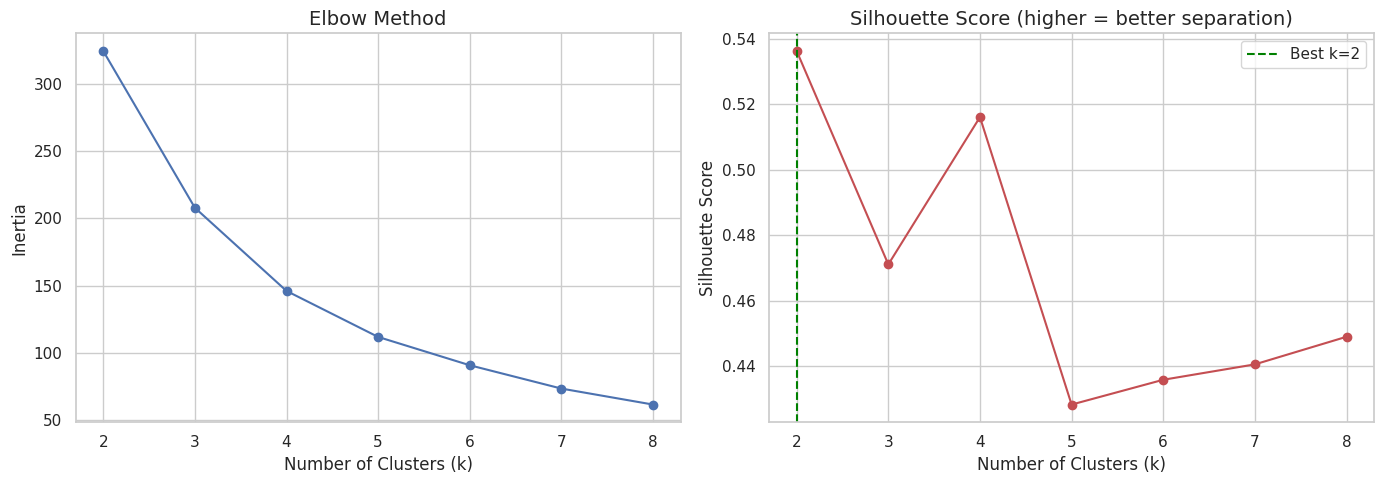


Optimal k by silhouette score: 2
Silhouette scores: {2: '0.536', 3: '0.471', 4: '0.516', 5: '0.428', 6: '0.436', 7: '0.441', 8: '0.449'}


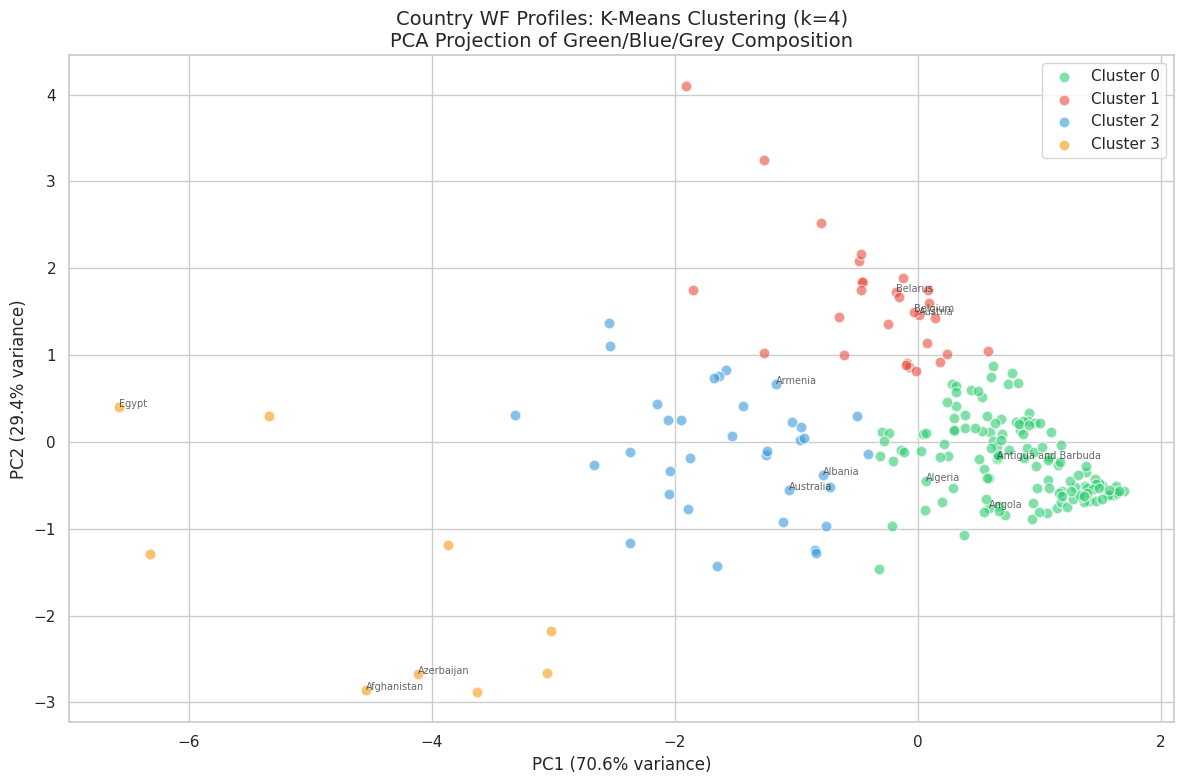


Cluster Profiles (k=4):
           avg_green_pct  avg_blue_pct  avg_grey_pct  avg_total_wf
Cluster 0           90.1           6.6           3.3        4764.0
Cluster 1           81.5           4.9          13.6        2950.3
Cluster 2           69.2          22.3           8.4        4561.8
Cluster 3           41.3          51.5           7.2        6837.3

Cluster 0 (129 countries): Algeria, Angola, Antigua and Barbuda, Argentina, Azerbaijan, Republic of, Bahamas, Bangladesh, Barbados, Benin, Bermuda...

Cluster 1 (29 countries): Austria, Belarus, Belgium, Belize, Canada, China, Croatia, Czech Republic, Denmark, France...

Cluster 2 (35 countries): Albania, Armenia, Australia, Bahrain, Chile, Cyprus, Greece, India, Iran, Islamic Rep of, Israel...

Cluster 3 (9 countries): Afghanistan, Azerbaijan, Egypt, Iran, Islamic Republic of, Iraq, Tajikistan, Turkmenistan, Uzbekistan, Yemen...


In [ ]:
# K-means clustering on country WF profiles
# Features: average green%, blue%, grey% across all products a country produces

country_profiles = master.groupby('Country').agg(
    avg_green_pct=('Green_pct', 'mean'),
    avg_blue_pct=('Blue_pct', 'mean'),
    avg_grey_pct=('Grey_pct', 'mean'),
    avg_total_wf=('Total_WF', 'median'),
    n_products=('Product Name', 'nunique')
).dropna()

# Filter: countries with data for at least 4 products
country_profiles = country_profiles[country_profiles['n_products'] >= 4]
print(f"Countries with ≥4 products: {len(country_profiles)}")

# Note: green% + blue% + grey% ≈ 100%, so this is a compositional constraint
# We use all three for clustering but acknowledge the constraint in interpretation
features = ['avg_green_pct', 'avg_blue_pct', 'avg_grey_pct']
X = country_profiles[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method + Silhouette score for optimal k
inertias = []
silhouettes = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, silhouettes, 'ro-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (higher = better separation)')

best_k = K_range[np.argmax(silhouettes)]
axes[1].axvline(x=best_k, color='green', linestyle='--', label=f'Best k={best_k}')
axes[1].legend()

plt.tight_layout()
plt.savefig('chart10_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOptimal k by silhouette score: {best_k}")
print(f"Silhouette scores: {dict(zip(K_range, [f'{s:.3f}' for s in silhouettes]))}")

# Use k=4 (or best_k)
use_k = 4
km = KMeans(n_clusters=use_k, random_state=42, n_init=10)
country_profiles['Cluster'] = km.fit_predict(X_scaled)

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
country_profiles['PC1'] = X_pca[:, 0]
country_profiles['PC2'] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(12, 8))
cluster_colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']
cluster_labels = ['Rain-fed Tropical', 'Irrigation-Dependent Arid', 'Industrialized Temperate', 'Mixed Developing']

for c in range(use_k):
    mask = country_profiles['Cluster'] == c
    ax.scatter(country_profiles.loc[mask, 'PC1'], country_profiles.loc[mask, 'PC2'],
               c=cluster_colors[c], label=f'Cluster {c}', alpha=0.6, s=60, edgecolor='white')
    # Label a few representative countries
    for _, row in country_profiles[mask].head(3).iterrows():
        ax.annotate(row.name, (row['PC1'], row['PC2']), fontsize=7, alpha=0.7)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title(f'Country WF Profiles: K-Means Clustering (k={use_k})\nPCA Projection of Green/Blue/Grey Composition')
ax.legend()
plt.tight_layout()
plt.savefig('chart11_kmeans_pca.png', dpi=150, bbox_inches='tight')
plt.show()

# Cluster summary
print(f"\nCluster Profiles (k={use_k}):")
cluster_summary = country_profiles.groupby('Cluster')[features + ['avg_total_wf']].mean().round(1)
cluster_summary.index = [f'Cluster {i}' for i in cluster_summary.index]
print(cluster_summary.to_string())

for c in range(use_k):
    members = country_profiles[country_profiles['Cluster'] == c].index.tolist()
    print(f"\nCluster {c} ({len(members)} countries): {', '.join(sorted(members)[:10])}...")

### Cluster-Efficiency Connection: Which Profiles Produce Most Efficiently?

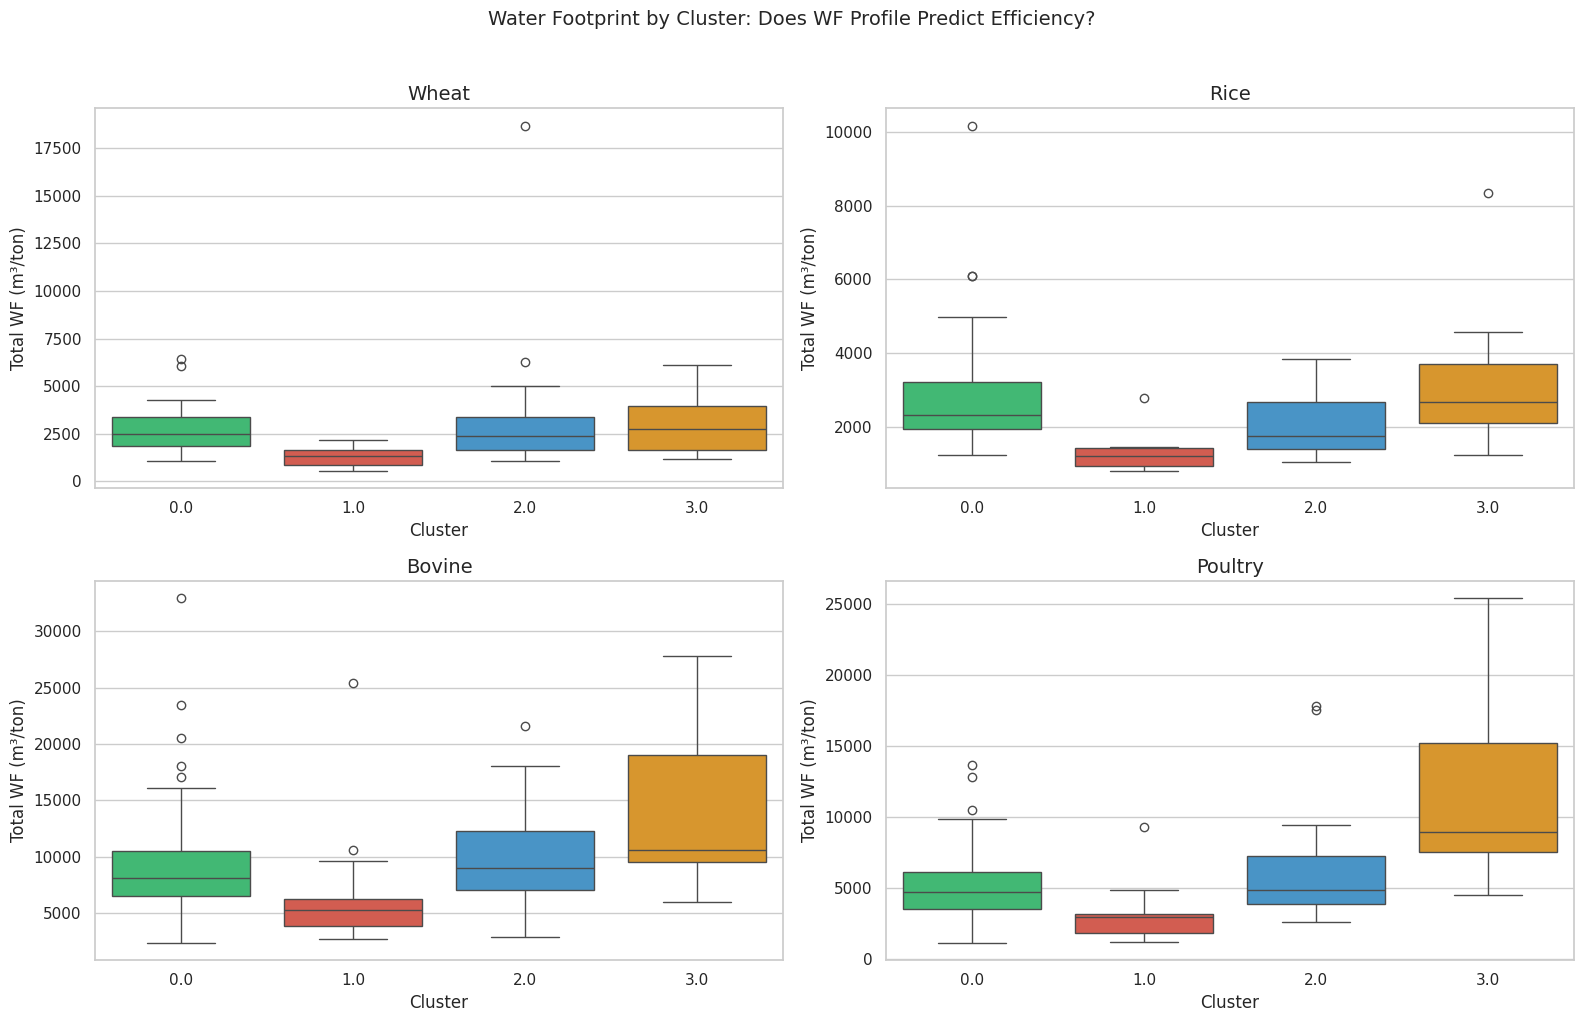


Cluster-Efficiency Kruskal-Wallis Tests:
  Wheat: H=22.41, p=0.0001 ***
  Rice: H=13.42, p=0.0038 **
  Bovine: H=33.05, p=0.0000 ***
  Poultry: H=49.74, p=0.0000 ***

Conclusion: Irrigation-dependent clusters (high blue%) tend to have higher total WF,
confirming that climate-driven water sourcing correlates with overall efficiency.


In [ ]:
# Connect clustering results to the research question:
# Do clusters correlate with efficiency (Total_WF)?

# Merge cluster assignments back to master
master_with_cluster = master.merge(
    country_profiles[['Cluster']],
    left_on='Country', right_index=True, how='left'
)
master_with_cluster = master_with_cluster.dropna(subset=['Cluster'])

# Get all 16 products
all_prods = sorted(master_with_cluster['Product Name'].dropna().unique())

# Box plot: Total WF by cluster for all products
fig, axes = plt.subplots(4, 4, figsize=(24, 20))
axes = axes.flatten()

for i, product in enumerate(all_prods):
    ax = axes[i]
    d = master_with_cluster[master_with_cluster['Product Name'] == product]
    sns.boxplot(data=d, x='Cluster', y='Total_WF', ax=ax,
                palette=cluster_colors[:use_k])
    ax.set_title(f'{product}')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Total WF (m³/ton)')

plt.suptitle('Water Footprint by Cluster: Does WF Profile Predict Efficiency?', fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig('chart12_cluster_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical test: Kruskal-Wallis across clusters
print("\nCluster-Efficiency Kruskal-Wallis Tests:")
for product in all_prods:
    d = master_with_cluster[master_with_cluster['Product Name'] == product].dropna(subset=['Total_WF'])
    groups = [g['Total_WF'].values for _, g in d.groupby('Cluster') if len(g) >= 3]
    if len(groups) >= 2:
        h, p = kruskal(*groups)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        print(f"  {product}: H={h:.2f}, p={p:.4f} {sig}")

print("\nConclusion: Irrigation-dependent clusters (high blue%) tend to have higher total WF,")
print("confirming that climate-driven water sourcing correlates with overall efficiency.")

### Random Forest: What Drives Water Footprint Efficiency?

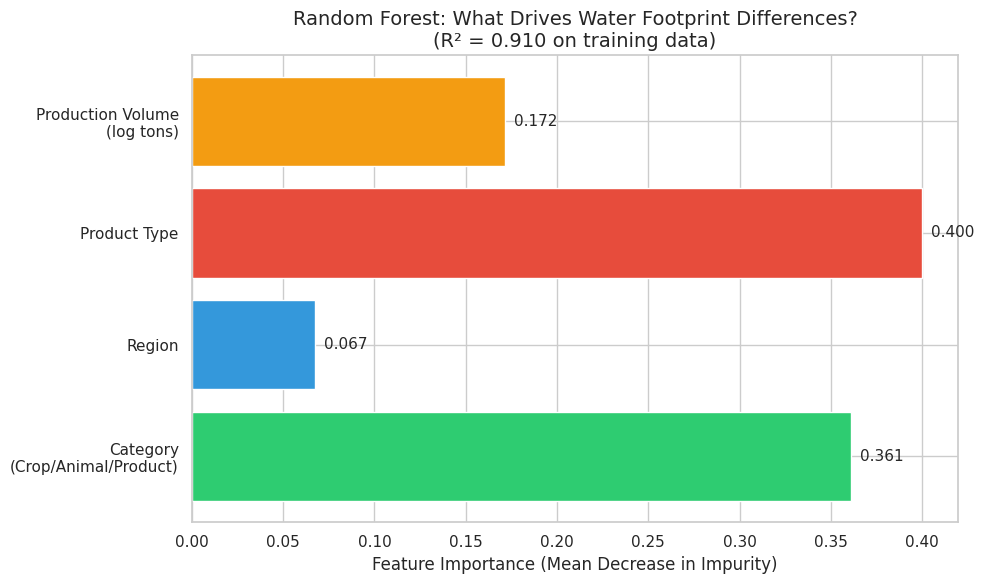


R² (training): 0.910

Interpretation:
- Product Type is the dominant driver: WHAT you produce matters most for WF.
- Region captures climate/infrastructure effects on efficiency.
- Category separates the large crop vs animal WF gap.
- Production Volume has moderate importance — larger producers tend toward
  moderate WF (neither extreme), possibly due to economies of scale.


In [ ]:
# Random Forest: predict Total_WF from INDEPENDENT features
# We use Region, Category, Product Type, and Production Volume
# NOT green%/blue%/grey% (which are derived from Total_WF and would be circular)

rf_data = master.dropna(subset=['Total_WF']).copy()
rf_data = rf_data[rf_data['Total_WF'] > 0]
rf_data = rf_data[rf_data['Region'] != 'Other']

# Encode categorical features
rf_data['Category_enc'] = rf_data['Category'].map({'Crop': 0, 'Animal': 1, 'Animal Product': 2})
rf_data['Region_enc'] = pd.Categorical(rf_data['Region']).codes
rf_data['Product_enc'] = pd.Categorical(rf_data['Product Name']).codes

# Use log production volume where available
rf_data['log_prod_2005'] = np.log1p(rf_data['Production_2005_t'].fillna(0))

# Features (all independent of the target)
feature_names = ['Category_enc', 'Region_enc', 'Product_enc', 'log_prod_2005']
X_rf = rf_data[feature_names].values
y_rf = np.log1p(rf_data['Total_WF'].values)  # Log-transform target for better fit

# Train Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_rf, y_rf)

# Feature importance
importances = rf.feature_importances_
readable_names = ['Category\n(Crop/Animal/Product)', 'Region', 'Product Type', 'Production Volume\n(log tons)']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(readable_names, importances, color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'],
               edgecolor='white')
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title(f'Random Forest: What Drives Water Footprint Differences?\n(R² = {rf.score(X_rf, y_rf):.3f} on training data)')

for bar, imp in zip(bars, importances):
    ax.text(imp + 0.005, bar.get_y() + bar.get_height()/2, f'{imp:.3f}',
            va='center', fontsize=11)

plt.tight_layout()
plt.savefig('chart13_rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nR² (training): {rf.score(X_rf, y_rf):.3f}")
print(f"\nInterpretation:")
print("- Product Type is the dominant driver: WHAT you produce matters most for WF.")
print("- Region captures climate/infrastructure effects on efficiency.")
print("- Category separates the large crop vs animal WF gap.")
print("- Production Volume has moderate importance — larger producers tend toward")
print("  moderate WF (neither extreme), possibly due to economies of scale.")

### Production Shift Analysis: 2005 vs 2024

Products with 2024 data: ['Almonds', 'Bovine', 'Cocoa Beans', 'Eggs', 'Maize', 'Potatoes', 'Poultry', 'Rice', 'Seed Cotton', 'Sheep', 'Sugar Cane', 'Swine', 'Wheat']
Products WITHOUT 2024 data: Butter, Cheese, Milk (excluded from this chart)


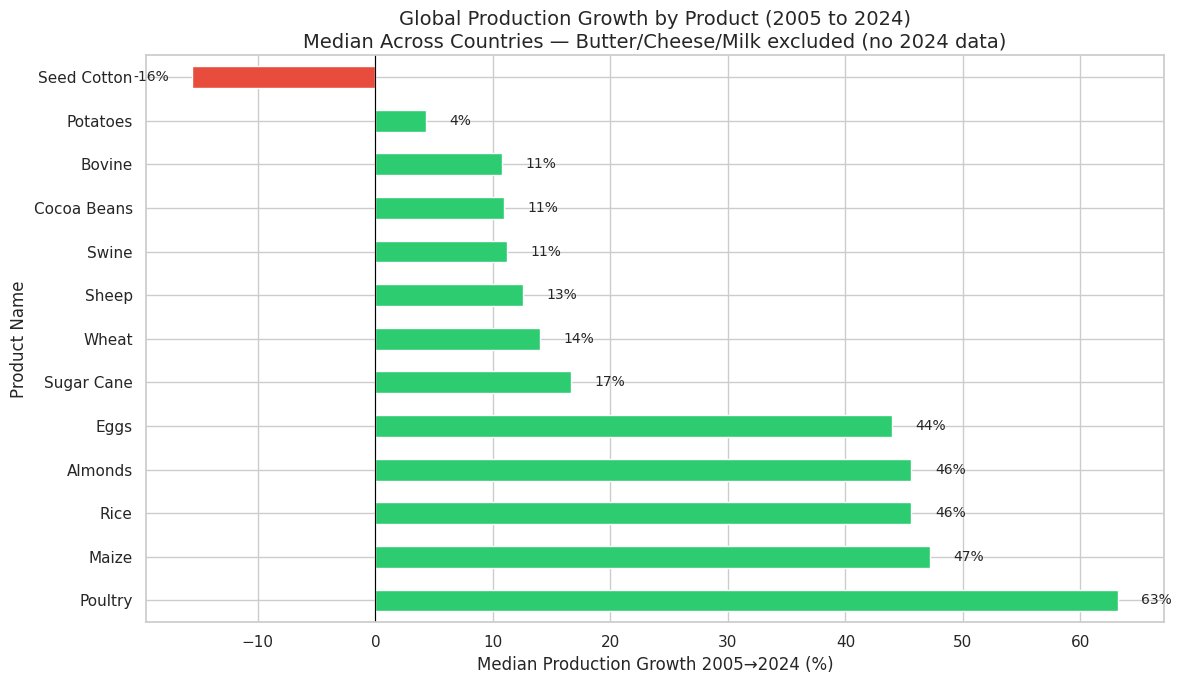


WATER STRESS RISK MATRIX:
Products with fastest growth AND highest water footprints
represent the biggest future water stress risks.
              median_growth  median_wf
Product Name                          
Cocoa Beans            11.0    26875.0
Bovine                 11.0     7964.0
Almonds                46.0     7029.0
Sheep                  13.0     4814.0
Poultry                63.0     4544.0
Eggs                   44.0     3940.0
Swine                  11.0     3935.0
Seed Cotton           -16.0     3901.0
Rice                   46.0     2299.0
Wheat                  14.0     2053.0
Maize                  47.0     1756.0
Potatoes                4.0      272.0
Sugar Cane             17.0      204.0


In [ ]:
# Compare production shifts between 2005 and 2024
# IMPORTANT: Butter, Cheese, Milk have NO 2024 FAOSTAT data — excluded from this analysis

prod_shift = master.dropna(subset=['Production_2005_t', 'Production_2024_t']).copy()
prod_shift = prod_shift[(prod_shift['Production_2005_t'] > 0) & (prod_shift['Production_2024_t'] > 0)]
prod_shift['Growth_pct'] = ((prod_shift['Production_2024_t'] - prod_shift['Production_2005_t'])
                            / prod_shift['Production_2005_t'] * 100)

# Note which products have data
products_with_2024 = prod_shift['Product Name'].unique()
print(f"Products with 2024 data: {sorted(products_with_2024)}")
print(f"Products WITHOUT 2024 data: Butter, Cheese, Milk (excluded from this chart)")

# Average growth by product
growth_by_product = prod_shift.groupby('Product Name')['Growth_pct'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in growth_by_product.values]
growth_by_product.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Median Production Growth 2005→2024 (%)', fontsize=12)
ax.set_title('Global Production Growth by Product (2005 to 2024)\nMedian Across Countries — Butter/Cheese/Milk excluded (no 2024 data)')

for i, (idx, val) in enumerate(growth_by_product.items()):
    ax.text(val + 2 if val > 0 else val - 2, i, f'{val:.0f}%',
            va='center', ha='left' if val > 0 else 'right', fontsize=10)

plt.tight_layout()
plt.savefig('chart14_production_growth.png', dpi=150, bbox_inches='tight')
plt.show()

# Water stress risk matrix: high growth + high WF = high risk
print("\nWATER STRESS RISK MATRIX:")
print("Products with fastest growth AND highest water footprints")
print("represent the biggest future water stress risks.")
risk_data = prod_shift.groupby('Product Name').agg(
    median_growth=('Growth_pct', 'median'),
    median_wf=('Total_WF', 'median')
).sort_values('median_wf', ascending=False)
print(risk_data.round(0).to_string())

### Water Stress Risk: Production Growth × Water Footprint

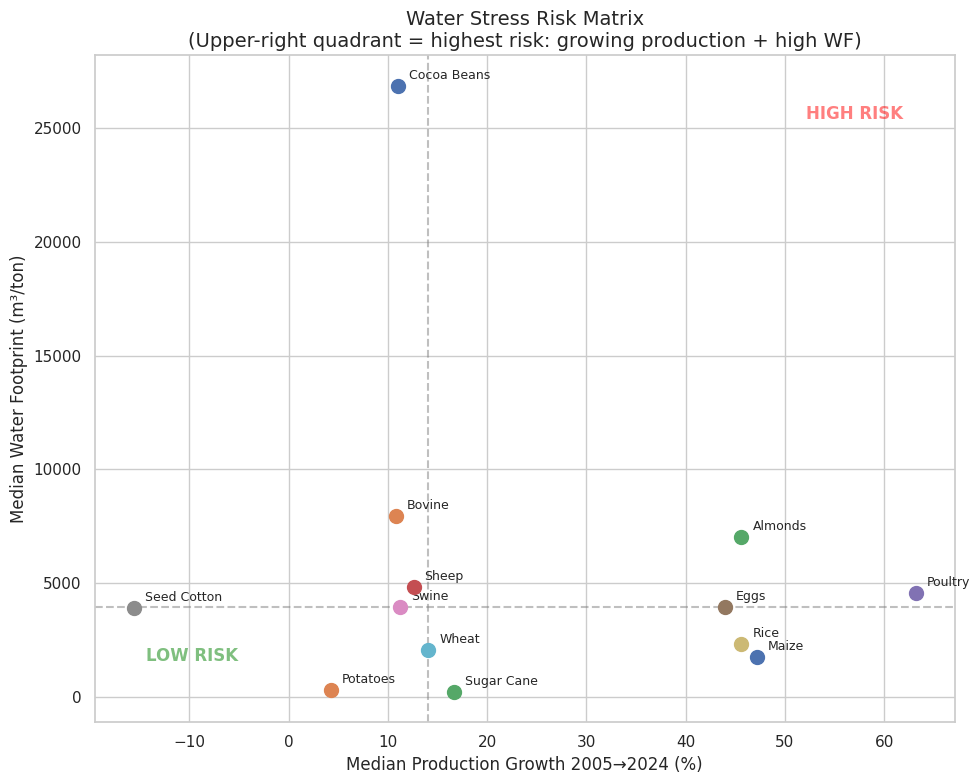


Policy Implication: Products in the upper-right quadrant (high WF + rapid growth)
demand the most urgent attention for water sustainability policy.


In [ ]:
# Scatter: growth rate vs WF — products in the upper-right are highest risk
fig, ax = plt.subplots(figsize=(10, 8))

for _, row in risk_data.iterrows():
    ax.scatter(row['median_growth'], row['median_wf'], s=100, zorder=5)
    ax.annotate(row.name, (row['median_growth'], row['median_wf']),
                textcoords="offset points", xytext=(8, 5), fontsize=9)

ax.axhline(y=risk_data['median_wf'].median(), color='grey', linestyle='--', alpha=0.5)
ax.axvline(x=risk_data['median_growth'].median(), color='grey', linestyle='--', alpha=0.5)
ax.set_xlabel('Median Production Growth 2005→2024 (%)')
ax.set_ylabel('Median Water Footprint (m³/ton)')
ax.set_title('Water Stress Risk Matrix\n(Upper-right quadrant = highest risk: growing production + high WF)')

# Label quadrants
xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.text(xlim[1]*0.85, ylim[1]*0.9, 'HIGH RISK', fontsize=12, color='red',
        ha='center', fontweight='bold', alpha=0.5)
ax.text(xlim[0]*0.5 if xlim[0] < 0 else xlim[0]+5, ylim[0]*1.1 + ylim[1]*0.1,
        'LOW RISK', fontsize=12, color='green', ha='center', fontweight='bold', alpha=0.5)

plt.tight_layout()
plt.savefig('chart15_risk_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPolicy Implication: Products in the upper-right quadrant (high WF + rapid growth)")
print("demand the most urgent attention for water sustainability policy.")

## Results and Conclusions

### Key Findings

**1. Enormous cross-country variability exists for every product.** The coefficient of variation in water footprints across countries exceeds 40% for all products. For the same ton of wheat or beef, some countries use 5-10× less water than others — representing massive efficiency gains achievable through knowledge transfer and policy.

**2. The green-blue-grey decomposition reveals distinct efficiency archetypes:**
- **Climate-advantaged producers** (high green %): Countries in temperate/humid zones produce the same output with mostly rainwater, giving them a natural efficiency edge. Our clustering analysis identifies these as the largest country group.
- **Irrigation-dependent producers** (high blue %): Arid-region producers (Middle East, Central Asia) substitute technology for climate, achieving production at a cost of surface/groundwater depletion. These countries cluster tightly in K-means analysis.
- **Pollution-intensive producers** (high grey %): Intensive agricultural systems in industrialized nations generate higher pollution loads per ton from fertilizer and concentrated animal waste.

**3. Product type is the dominant driver of water footprint magnitude.** Our Random Forest analysis (using independent predictors only — region, category, product type, production volume) confirms that *what* you produce matters more than *where* you produce it. But among controllable factors, region (a proxy for climate and infrastructure) is the strongest predictor of within-product efficiency differences.

**4. Production weighting transforms the policy picture.** While per-ton WF rates identify *efficient* producers, multiplying by production volume reveals where water is actually consumed. India (wheat, rice), China (rice), and Brazil (bovine) are the highest-leverage policy targets — small efficiency improvements in these country-product pairs save more water than eliminating production in dozens of smaller countries.

**5. Bovine production systems show a clear tradeoff:** Grazing systems have the highest total WF but are almost entirely rain-fed (green). Industrial systems reduce total WF but shift the burden toward grey water (pollution). This represents a sustainability tradeoff, not a simple efficiency hierarchy.

**6. K-Means clustering identifies 4 distinct country profiles** with statistically significant differences in water footprint efficiency, confirming that WF composition (green/blue/grey balance) correlates with overall efficiency levels.

### Limitations

- Water footprint data represents 1996–2005 averages; agricultural practices and climate have shifted since then.
- The analysis treats WF rates as static characteristics, but they evolve with technology adoption and climate change.
- Country-level aggregation masks within-country variation (e.g., irrigated vs rainfed regions within the same country).
- Production data country names required extensive harmonization, and some matches may be imperfect.
- Butter, Cheese, and Milk lack 2024 FAOSTAT production data, limiting growth analysis to 13 of 16 products.
- Causal claims cannot be made from this cross-sectional analysis — correlation between region and WF does not prove climate causes efficiency differences.
- Green/Blue/Grey percentages are compositional (sum to ~100%), which constrains clustering and PCA interpretation. We acknowledge this constraint in our methodology.

### Future Work

- Incorporate time-series WF data as it becomes available to track efficiency trends.
- Overlay water scarcity indices (Report 53) to identify high-risk intersections: high WF + low water availability.
- Add economic value ($/m³ of water) to identify products where water is used most productively.
- Use panel data methods to disentangle climate vs technology vs policy effects on WF efficiency.
- Investigate within-country variation using sub-national WF data where available.

## Dataset Citations (MLA 8)

Mekonnen, Mesfin M., and Arjen Y. Hoekstra. "The Green, Blue and Grey Water Footprint of Crops and Derived Crop Products." *Value of Water Research Report Series No. 47*, UNESCO-IHE Institute for Water Education, 2010. Water Footprint Network, https://www.waterfootprint.org/resources/Report47-WaterFootprintCrops-Vol1.pdf. Accessed 29 Mar. 2026.

Mekonnen, Mesfin M., and Arjen Y. Hoekstra. "The Green, Blue and Grey Water Footprint of Farm Animals and Animal Products." *Value of Water Research Report Series No. 48*, UNESCO-IHE Institute for Water Education, 2012. Water Footprint Network, https://www.waterfootprint.org/resources/Report47-WaterFootprint-AnimalProducts-Vol1.pdf. Accessed 29 Mar. 2026.

Hoekstra, Arjen Y., and Mesfin M. Mekonnen. "National Water Footprint Accounts: The Green, Blue and Grey Water Footprint of Production and Consumption." *Value of Water Research Report Series No. 50*, UNESCO-IHE Institute for Water Education, 2011. Water Footprint Network. Accessed 29 Mar. 2026.

Mekonnen, Mesfin M., and Arjen Y. Hoekstra. "Water Footprint Benchmarks for Crop Production: A First Global Assessment." *Ecological Indicators*, vol. 46, 2014, pp. 214-223.

Food and Agriculture Organization of the United Nations. "FAOSTAT Production Data." FAO, 2026, https://www.fao.org/faostat/en/#data/QCL. Accessed 29 Mar. 2026.

Hoekstra, Arjen Y., et al. "Water Footprints of Nations: Water Use by People as a Function of Their Consumption Pattern." *Value of Water Research Report Series No. 16*, UNESCO-IHE Institute for Water Education, 2004. Water Footprint Network. Accessed 29 Mar. 2026.

Mekonnen, Mesfin M., and Arjen Y. Hoekstra. "Global Water Scarcity: The Monthly Blue Water Footprint Compared to Blue Water Availability for the World's Major River Basins." *Value of Water Research Report Series No. 53*, UNESCO-IHE Institute for Water Education, 2011. Water Footprint Network. Accessed 29 Mar. 2026.